In [6]:
# ============================================================
# QCTrojan-Bench: Quantum Circuit Trojan Detection Benchmark
# ============================================================
# Notebook:  S5_models.ipynb
# Purpose:   Train and evaluate classical ML models for
#            malicious quantum circuit detection.
#
#            Experiments:
#              A — IID repeated CV (5-fold × 3 repeats)
#              B — Leave-one-family-out holdout
#              C — Feature ablation study
#
# Authors:   Zeeshan Ajmal
#            University of Oulu, Finland
# Version:   QCTrojan-Bench v1.0
# License:   CC BY 4.0
# ============================================================
#
# CELL 1 — Imports, Configuration, Load Data
#
# Prerequisites:
#   S3 complete — features_v1.csv exists
#   S4 complete — split_index.csv exists
# ============================================================

import os
import json
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import friedmanchisquare

# ── Publication figure settings ───────────────────────────────
matplotlib.rcParams.update({
    "figure.dpi":     300,
    "font.size":      10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.family":    "serif",
})

# ── Versioning ────────────────────────────────────────────────
SEED = 42

# ── Paths ─────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
FEATURES_DIR = PROJECT_ROOT / "dataset" / "features"
RESULTS_DIR  = PROJECT_ROOT / "results"

FEATURES_PATH = FEATURES_DIR / "features_v1.csv"
SPLIT_PATH    = FEATURES_DIR / "split_index.csv"

for subdir in ["exp_iid", "exp_holdout",
               "exp_ablation", "figures"]:
    (RESULTS_DIR / subdir).mkdir(parents=True, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────
df    = pd.read_csv(FEATURES_PATH)
split = pd.read_csv(SPLIT_PATH)

# Merge split index into main dataframe
fold_cols = [c for c in split.columns
             if c.startswith("fold_iid_r")]
N_REPEATS = len(fold_cols)
N_FOLDS   = 5

df = df.merge(
    split[["sample_id"] + fold_cols + ["holdout_family"]],
    on="sample_id",
    how="left",
)

# ── Feature and label setup ───────────────────────────────────
META_COLS = [
    "sample_id", "parent_sample_id", "label",
    "trojan_type", "algorithm_family", "n_qubits",
    "holdout_family",
] + fold_cols

FEATURE_COLS = [
    c for c in df.columns if c not in META_COLS
]

# Three-class target: benign, static, triggered
CLASS_ORDER = ["benign", "static", "triggered"]
le = LabelEncoder()
le.fit(CLASS_ORDER)
y_all = le.transform(df["trojan_type"].values)
X_all = df[FEATURE_COLS].values.astype(float)

assert np.isnan(X_all).sum() == 0, "NaNs in feature matrix"

FAMILIES = sorted(df["algorithm_family"].unique().tolist())

# ── Summary ───────────────────────────────────────────────────
print("=" * 55)
print("QCTrojan-Bench — S5 Model Training")
print("=" * 55)
print(f"  Seed            : {SEED}")
print(f"  Features        : {len(FEATURE_COLS)}")
print(f"  Circuits        : {len(df)}")
print(f"  Classes         : {CLASS_ORDER}")
print(f"  CV protocol     : {N_FOLDS}-fold × {N_REPEATS} repeats")
print(f"  Families        : {FAMILIES}")
print("=" * 55)
print("Cell 1 complete. Ready for Cell 2.")


QCTrojan-Bench — S5 Model Training
  Seed            : 42
  Features        : 39
  Circuits        : 9000
  Classes         : ['benign', 'static', 'triggered']
  CV protocol     : 5-fold × 3 repeats
  Families        : ['deutsch_jozsa', 'grover', 'qaoa', 'qft', 'vqc']
Cell 1 complete. Ready for Cell 2.


In [9]:
# ============================================================
# CELL 2 — Model Definitions
# ============================================================
#
# Defines all three classical ML models used in the study.
# Models are defined once here and reused across all
# experimental components.
#
# Models:
#   random_forest : 500 trees, balanced subsample weights
#   linear_svm    : linear kernel, balanced class weights
#   rbf_svm       : RBF kernel, balanced class weights
#
# All seeds fixed at SEED=42 for reproducibility.
# SVM models include StandardScaler in pipeline.
#
# These are the exact hyperparameters reported in the paper.
# Do NOT change after experiments begin.
# ============================================================

# Fixed class label array used everywhere
N_CLASSES   = len(CLASS_ORDER)
CLASS_LABELS = np.arange(N_CLASSES)  # [0, 1, 2]


def make_models():
    """
    Return a fresh dict of unfitted model instances.
    Call this function each time you need clean models
    to avoid state leakage between experiments.
    """
    return {
        "random_forest": RandomForestClassifier(
            n_estimators=500,
            random_state=SEED,
            n_jobs=-1,
            class_weight="balanced_subsample",
            max_features="sqrt",
        ),
        "linear_svm": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="linear",
                class_weight="balanced",
                probability=True,
                random_state=SEED,
            )),
        ]),
        "rbf_svm": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                gamma="scale",
                class_weight="balanced",
                probability=True,
                random_state=SEED,
            )),
        ]),
    }


def evaluate(model, X_train, y_train,
             X_test, y_test) -> dict:
    """
    Fit model and return evaluation metrics.

    Metrics:
        balanced_accuracy : primary metric
        f1_macro          : secondary metric
        roc_auc_ovr       : discrimination (one-vs-rest macro)
        y_pred            : predicted labels (for McNemar)
        y_prob            : predicted probabilities (for AUC)

    Note: labels parameter is passed explicitly to roc_auc_score
    to handle cases where not all classes appear in y_test.
    """
    m = copy.deepcopy(model)
    m.fit(X_train, y_train)

    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)

    # Ensure y_prob has columns for all classes
    # even if some are absent from this fold's test set
    n_train_classes = y_prob.shape[1]
    if n_train_classes < N_CLASSES:
        # Pad missing class columns with zeros
        full_prob = np.zeros((len(y_test), N_CLASSES))
        trained_classes = m.classes_ \
            if hasattr(m, "classes_") \
            else m.named_steps["clf"].classes_
        for i, cls in enumerate(trained_classes):
            full_prob[:, cls] = y_prob[:, i]
        y_prob = full_prob

    return {
        "balanced_accuracy": balanced_accuracy_score(
            y_test, y_pred
        ),
        "f1_macro": f1_score(
            y_test, y_pred,
            average="macro",
            zero_division=0,
        ),
        "roc_auc_ovr": roc_auc_score(
            y_test, y_prob,
            multi_class="ovr",
            average="macro",
            labels=CLASS_LABELS,
        ),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "model":  m,
    }


# ── Smoke test ────────────────────────────────────────────────
# Use balanced classes guaranteed to have all 3 in test set

_models  = make_models()
_rng     = np.random.RandomState(0)
_n       = 300  # 100 per class
_X_smoke = _rng.randn(_n, len(FEATURE_COLS))
_y_smoke = np.array([0]*100 + [1]*100 + [2]*100)

# Stratified split: 80% train, 20% test
_train_idx = np.concatenate([
    np.arange(0, 80), np.arange(100, 180), np.arange(200, 280)
])
_test_idx = np.concatenate([
    np.arange(80, 100), np.arange(180, 200), np.arange(280, 300)
])

for name, model in _models.items():
    result = evaluate(
        model,
        _X_smoke[_train_idx], _y_smoke[_train_idx],
        _X_smoke[_test_idx],  _y_smoke[_test_idx],
    )
    print(f"  {name:15s} — smoke test passed  "
          f"bal_acc={result['balanced_accuracy']:.3f}  "
          f"f1={result['f1_macro']:.3f}  "
          f"auc={result['roc_auc_ovr']:.3f}")

print()
print("Models defined:")
for name in make_models():
    print(f"  {name}")
print()
print("Cell 2 complete. Models ready.")


  random_forest   — smoke test passed  bal_acc=0.350  f1=0.352  auc=0.477
  linear_svm      — smoke test passed  bal_acc=0.417  f1=0.413  auc=0.514
  rbf_svm         — smoke test passed  bal_acc=0.367  f1=0.364  auc=0.560

Models defined:
  random_forest
  linear_svm
  rbf_svm

Cell 2 complete. Models ready.


Experiment A — IID Repeated CV
Total fits: 45 (3 repeats × 5 folds × 3 models)
  [  1/45] repeat=0 fold=0 random_forest   — bal_acc=0.951  f1=0.951  auc=0.996
  [  2/45] repeat=0 fold=0 linear_svm      — bal_acc=0.733  f1=0.730  auc=0.896
  [  3/45] repeat=0 fold=0 rbf_svm         — bal_acc=0.745  f1=0.745  auc=0.915
  [  4/45] repeat=0 fold=1 random_forest   — bal_acc=0.949  f1=0.949  auc=0.996
  [  5/45] repeat=0 fold=1 linear_svm      — bal_acc=0.717  f1=0.715  auc=0.890
  [  6/45] repeat=0 fold=1 rbf_svm         — bal_acc=0.743  f1=0.743  auc=0.906
  [  7/45] repeat=0 fold=2 random_forest   — bal_acc=0.958  f1=0.958  auc=0.997
  [  8/45] repeat=0 fold=2 linear_svm      — bal_acc=0.726  f1=0.724  auc=0.899
  [  9/45] repeat=0 fold=2 rbf_svm         — bal_acc=0.758  f1=0.758  auc=0.912
  [ 10/45] repeat=0 fold=3 random_forest   — bal_acc=0.953  f1=0.953  auc=0.997
  [ 11/45] repeat=0 fold=3 linear_svm      — bal_acc=0.727  f1=0.726  auc=0.902
  [ 12/45] repeat=0 fold=3 rbf_svm       

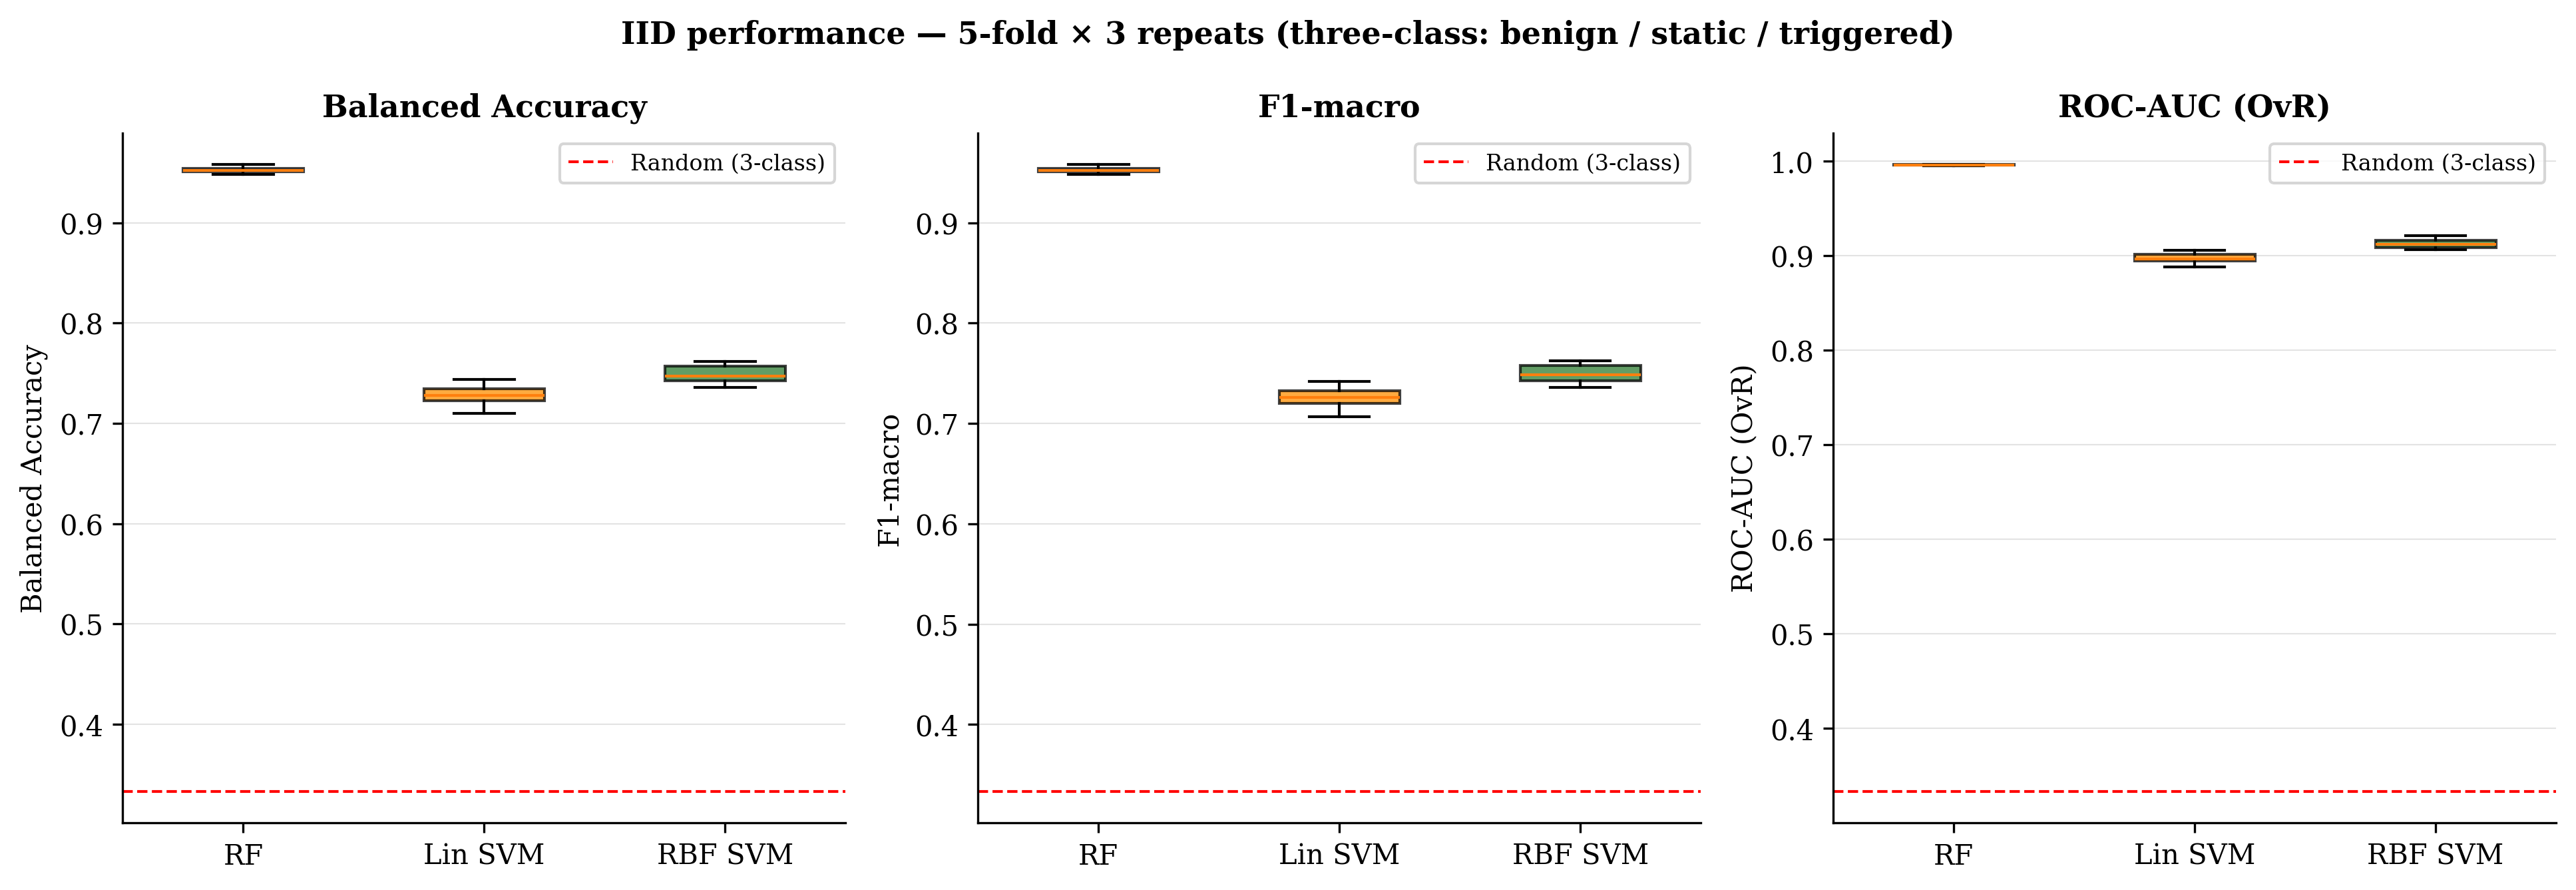

Saved: iid_boxplot.png / .pdf


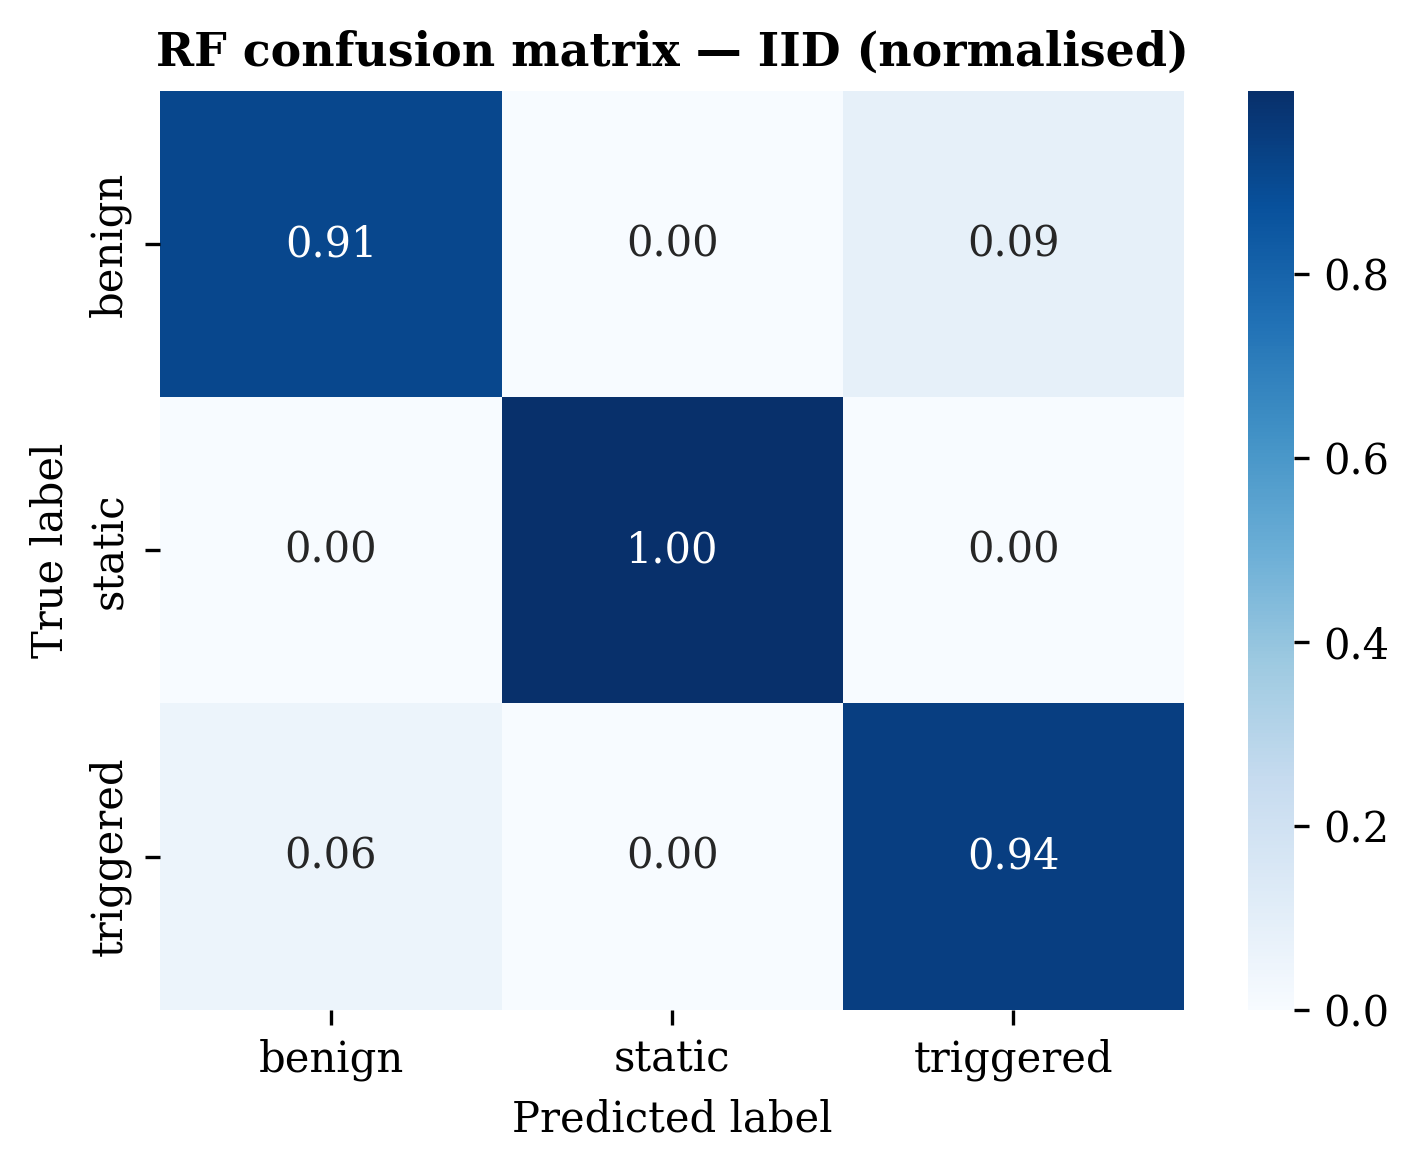

Saved: rf_confusion_matrix_iid.png / .pdf
Saved: iid_raw_results.json

Cell 3 complete — Experiment A done.


In [11]:
# ============================================================
# CELL 3 — Experiment A: IID Repeated Stratified CV
# ============================================================
#
# Protocol:
#   5-fold × 3 repeats = 15 evaluation points per model.
#   Source-circuit stratified (from split_index.csv).
#   Three-class: benign vs static vs triggered.
#
# Models: Random Forest, Linear SVM, RBF SVM
#
# Metrics per fold:
#   - Balanced accuracy (primary)
#   - F1-macro (secondary)
#   - ROC-AUC one-vs-rest macro
#
# Outputs:
#   results/exp_iid/iid_summary.csv
#   results/exp_iid/iid_raw_results.json
#   results/exp_iid/iid_boxplot.png
#   results/exp_iid/rf_confusion_matrix_iid.png
#   results/exp_iid/mcnemar_test.json
#
# ============================================================

IID_DIR = RESULTS_DIR / "exp_iid"
models  = make_models()

# Results storage
# results[model_name][metric] = list of 15 fold values
iid_results = {m: defaultdict(list) for m in models}

# Store all predictions for McNemar test
all_preds = {m: [] for m in models}  # list of (y_true, y_pred)

total_fits = N_REPEATS * N_FOLDS * len(models)
fit_count  = 0

print("=" * 55)
print("Experiment A — IID Repeated CV")
print(f"Total fits: {total_fits} "
      f"({N_REPEATS} repeats × {N_FOLDS} folds × "
      f"{len(models)} models)")
print("=" * 55)

for repeat in range(N_REPEATS):
    fold_col = f"fold_iid_r{repeat}"

    for fold in range(N_FOLDS):
        train_mask = df[fold_col] != fold
        test_mask  = df[fold_col] == fold

        X_train = X_all[train_mask]
        y_train = y_all[train_mask]
        X_test  = X_all[test_mask]
        y_test  = y_all[test_mask]

        for model_name, model in models.items():
            result = evaluate(
                model, X_train, y_train, X_test, y_test
            )

            iid_results[model_name]["balanced_accuracy"].append(
                result["balanced_accuracy"]
            )
            iid_results[model_name]["f1_macro"].append(
                result["f1_macro"]
            )
            iid_results[model_name]["roc_auc_ovr"].append(
                result["roc_auc_ovr"]
            )
            all_preds[model_name].append(
                (y_test, result["y_pred"])
            )

            fit_count += 1
            print(
                f"  [{fit_count:3d}/{total_fits}] "
                f"repeat={repeat} fold={fold} "
                f"{model_name:15s} — "
                f"bal_acc={result['balanced_accuracy']:.3f}  "
                f"f1={result['f1_macro']:.3f}  "
                f"auc={result['roc_auc_ovr']:.3f}"
            )

print("\nCV complete.")

# ── Summary table ─────────────────────────────────────────────

print("\n" + "=" * 55)
print("IID Results Summary (mean ± std)")
print("=" * 55)
print(f"{'Model':<16} {'Bal.Acc':>10} {'F1-macro':>10} "
      f"{'ROC-AUC':>10}")
print("-" * 55)

summary_rows = []
for model_name in models:
    r = iid_results[model_name]
    bal_mean = np.mean(r["balanced_accuracy"])
    bal_std  = np.std(r["balanced_accuracy"])
    f1_mean  = np.mean(r["f1_macro"])
    f1_std   = np.std(r["f1_macro"])
    auc_mean = np.mean(r["roc_auc_ovr"])
    auc_std  = np.std(r["roc_auc_ovr"])

    print(
        f"  {model_name:<14} "
        f"{bal_mean:.3f}±{bal_std:.3f}  "
        f"{f1_mean:.3f}±{f1_std:.3f}  "
        f"{auc_mean:.3f}±{auc_std:.3f}"
    )

    summary_rows.append({
        "model":              model_name,
        "bal_acc_mean":       round(bal_mean, 4),
        "bal_acc_std":        round(bal_std,  4),
        "f1_macro_mean":      round(f1_mean,  4),
        "f1_macro_std":       round(f1_std,   4),
        "roc_auc_mean":       round(auc_mean, 4),
        "roc_auc_std":        round(auc_std,  4),
    })

# Save summary CSV
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(IID_DIR / "iid_summary.csv", index=False)
print(f"\nSaved: iid_summary.csv")

# ── McNemar test: RF vs best SVM ──────────────────────────────

svm_names = ["linear_svm", "rbf_svm"]
best_svm  = max(
    svm_names,
    key=lambda m: np.mean(iid_results[m]["balanced_accuracy"])
)
print(f"\nMcNemar test: random_forest vs {best_svm}")

rf_preds   = np.concatenate(
    [p for _, p in all_preds["random_forest"]]
)
svm_preds  = np.concatenate(
    [p for _, p in all_preds[best_svm]]
)
y_true_all = np.concatenate(
    [t for t, _ in all_preds["random_forest"]]
)

rf_correct  = (rf_preds  == y_true_all).astype(int)
svm_correct = (svm_preds == y_true_all).astype(int)

b = int(np.sum((rf_correct == 1) & (svm_correct == 0)))
c = int(np.sum((rf_correct == 0) & (svm_correct == 1)))

table = np.array([
    [int(np.sum((rf_correct == 1) & (svm_correct == 1))), b],
    [c, int(np.sum((rf_correct == 0) & (svm_correct == 0)))],
])

mc_result = mcnemar(table, exact=False, correction=True)
sig = mc_result.pvalue < 0.05

print(f"  b (RF correct, SVM wrong) : {b}")
print(f"  c (SVM correct, RF wrong) : {c}")
print(f"  chi2 = {mc_result.statistic:.4f}")
print(f"  p    = {mc_result.pvalue:.6f}")
print(f"  Significant at p<0.05     : {sig}")

mcnemar_out = {
    "model_a":          "random_forest",
    "model_b":          best_svm,
    "b":                b,
    "c":                c,
    "chi2":             float(mc_result.statistic),
    "p_value":          float(mc_result.pvalue),
    "significant_p005": bool(sig),
}
with open(IID_DIR / "mcnemar_test.json", "w") as f:
    json.dump(mcnemar_out, f, indent=2)
print(f"Saved: mcnemar_test.json")

# ── Boxplot ───────────────────────────────────────────────────

metrics      = ["balanced_accuracy", "f1_macro", "roc_auc_ovr"]
metric_labels = ["Balanced Accuracy", "F1-macro", "ROC-AUC (OvR)"]
colors        = {
    "random_forest": "#1565C0",
    "linear_svm":    "#FF8F00",
    "rbf_svm":       "#2E7D32",
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, metric, label in zip(axes, metrics, metric_labels):
    data  = [iid_results[m][metric] for m in models]
    names = list(models.keys())
    bp    = ax.boxplot(
        data,
        patch_artist=True,
        notch=False,
        widths=0.5,
    )
    for patch, name in zip(bp["boxes"], names):
        patch.set_facecolor(colors[name])
        patch.set_alpha(0.75)

    ax.set_xticklabels(["RF", "Lin SVM", "RBF SVM"],
                       fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.axhline(
        1/3, color="red", linestyle="--",
        linewidth=1, label="Random (3-class)",
    )
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.35, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "IID performance — 5-fold × 3 repeats "
    "(three-class: benign / static / triggered)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
fig.savefig(IID_DIR / "iid_boxplot.png",
            dpi=300, bbox_inches="tight")
fig.savefig(IID_DIR / "iid_boxplot.pdf",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: iid_boxplot.png / .pdf")

# ── RF confusion matrix (last fold, last repeat) ──────────────

last_repeat   = N_REPEATS - 1
last_fold     = N_FOLDS - 1
fold_col      = f"fold_iid_r{last_repeat}"
train_mask    = df[fold_col] != last_fold
test_mask     = df[fold_col] == last_fold

rf_final = copy.deepcopy(models["random_forest"])
rf_final.fit(X_all[train_mask], y_all[train_mask])
y_pred_final = rf_final.predict(X_all[test_mask])
y_true_final = y_all[test_mask]

cm      = confusion_matrix(y_true_final, y_pred_final)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm_norm, annot=True, fmt=".2f", cmap="Blues",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax,
)
ax.set_ylabel("True label", fontsize=10)
ax.set_xlabel("Predicted label", fontsize=10)
ax.set_title(
    "RF confusion matrix — IID (normalised)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
fig.savefig(IID_DIR / "rf_confusion_matrix_iid.png",
            dpi=300, bbox_inches="tight")
fig.savefig(IID_DIR / "rf_confusion_matrix_iid.pdf",
            dpi=300, bbox_inches="tight")
plt.show()
print("Saved: rf_confusion_matrix_iid.png / .pdf")

# ── Save raw results ──────────────────────────────────────────

raw = {
    m: {
        metric: [float(v) for v in vals]
        for metric, vals in iid_results[m].items()
    }
    for m in models
}
raw["_meta"] = {
    "created":   datetime.now(timezone.utc).isoformat(),
    "seed":      SEED,
    "n_folds":   N_FOLDS,
    "n_repeats": N_REPEATS,
    "classes":   CLASS_ORDER,
}
with open(IID_DIR / "iid_raw_results.json", "w") as f:
    json.dump(raw, f, indent=2)
print("Saved: iid_raw_results.json")

print("\nCell 3 complete — Experiment A done.")


Experiment B — Leave-One-Family-Out Holdout

  Holdout: deutsch_jozsa
    Train: 7200 circuits
    Test : 1800 circuits
    random_forest   — bal_acc=0.733  f1=0.727  recall: benign=0.49  static=1.00  triggered=0.70
    linear_svm      — bal_acc=0.630  f1=0.540  recall: benign=0.84  static=1.00  triggered=0.05
    rbf_svm         — bal_acc=0.396  f1=0.381  recall: benign=0.57  static=0.41  triggered=0.20

  Holdout: grover
    Train: 7200 circuits
    Test : 1800 circuits
    random_forest   — bal_acc=1.000  f1=1.000  recall: benign=1.00  static=1.00  triggered=1.00
    linear_svm      — bal_acc=0.550  f1=0.567  recall: benign=0.65  static=0.63  triggered=0.38
    rbf_svm         — bal_acc=0.355  f1=0.210  recall: benign=1.00  static=0.07  triggered=0.00

  Holdout: qaoa
    Train: 7200 circuits
    Test : 1800 circuits
    random_forest   — bal_acc=0.497  f1=0.409  recall: benign=0.00  static=0.49  triggered=1.00
    linear_svm      — bal_acc=0.361  f1=0.250  recall: benign=0.03  stat

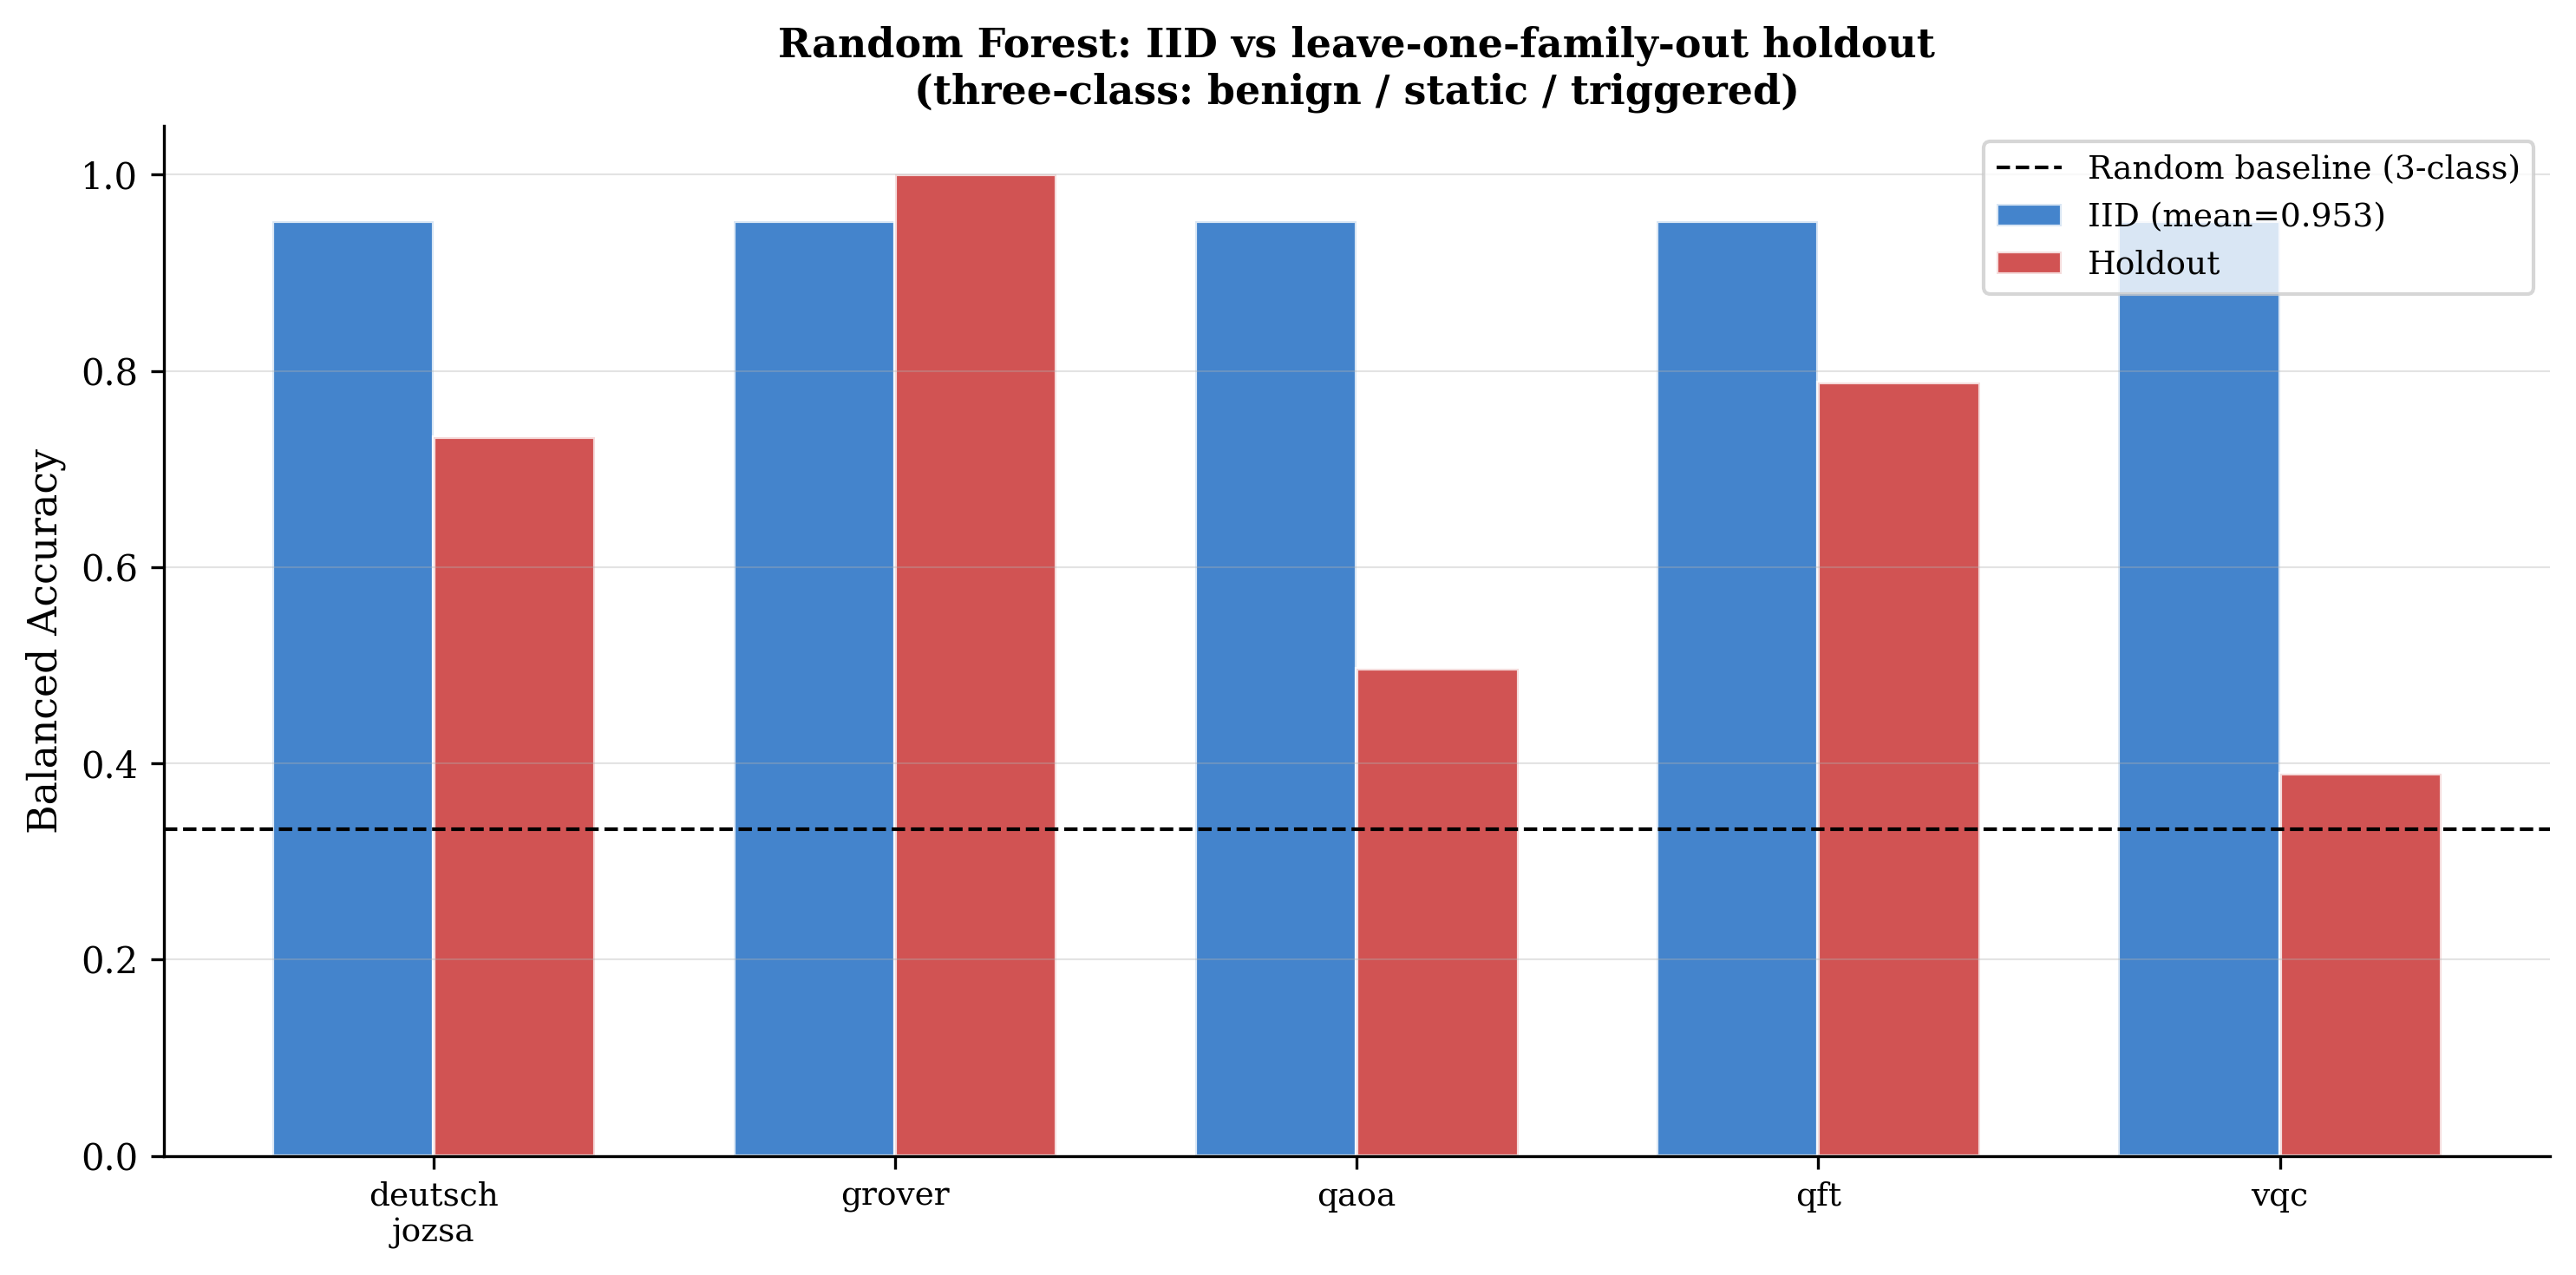

Saved: holdout_bar_chart.png / .pdf


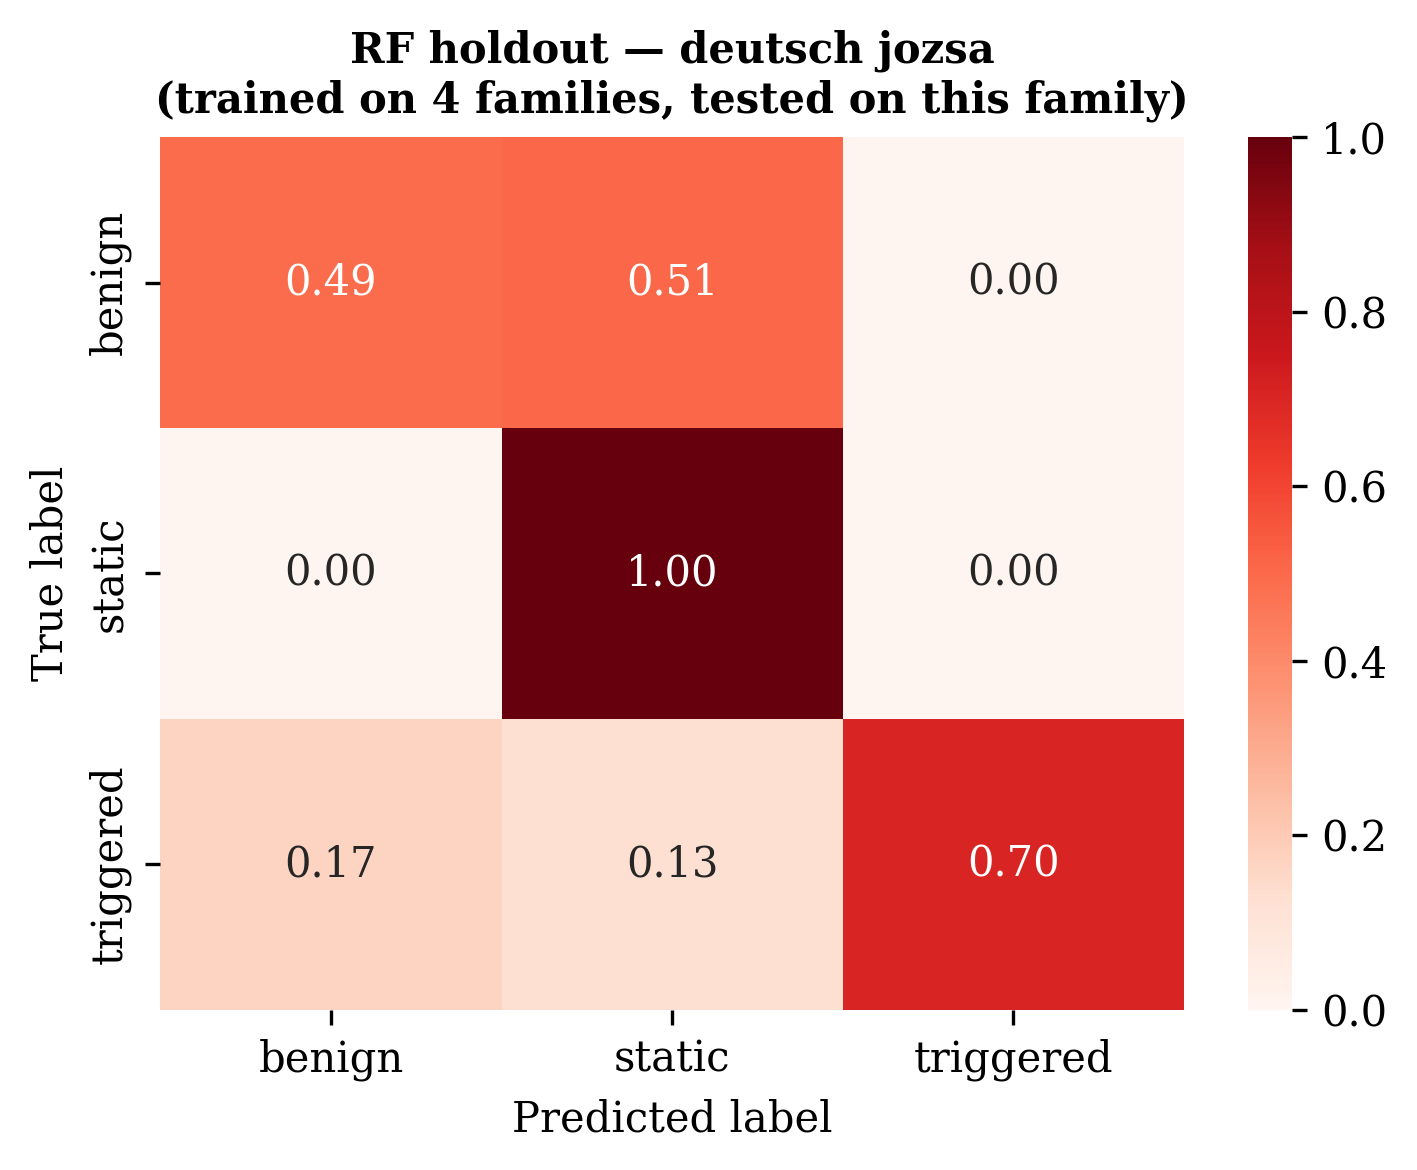

Saved: holdout_confusion_deutsch_jozsa.png / .pdf


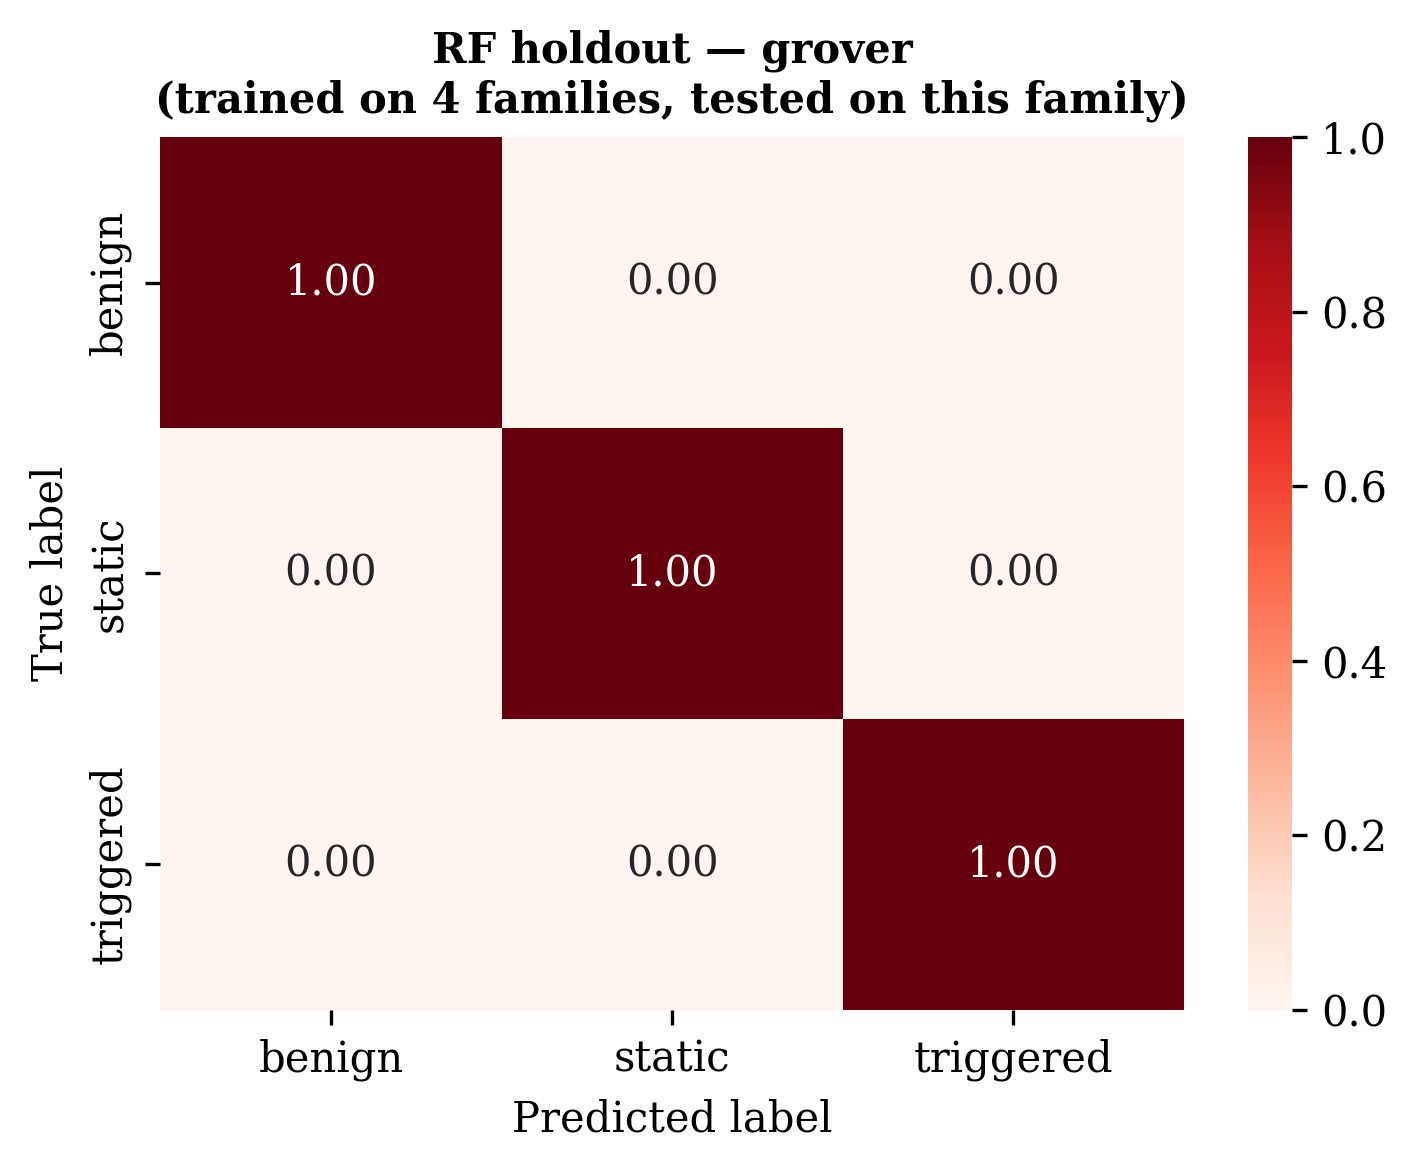

Saved: holdout_confusion_grover.png / .pdf


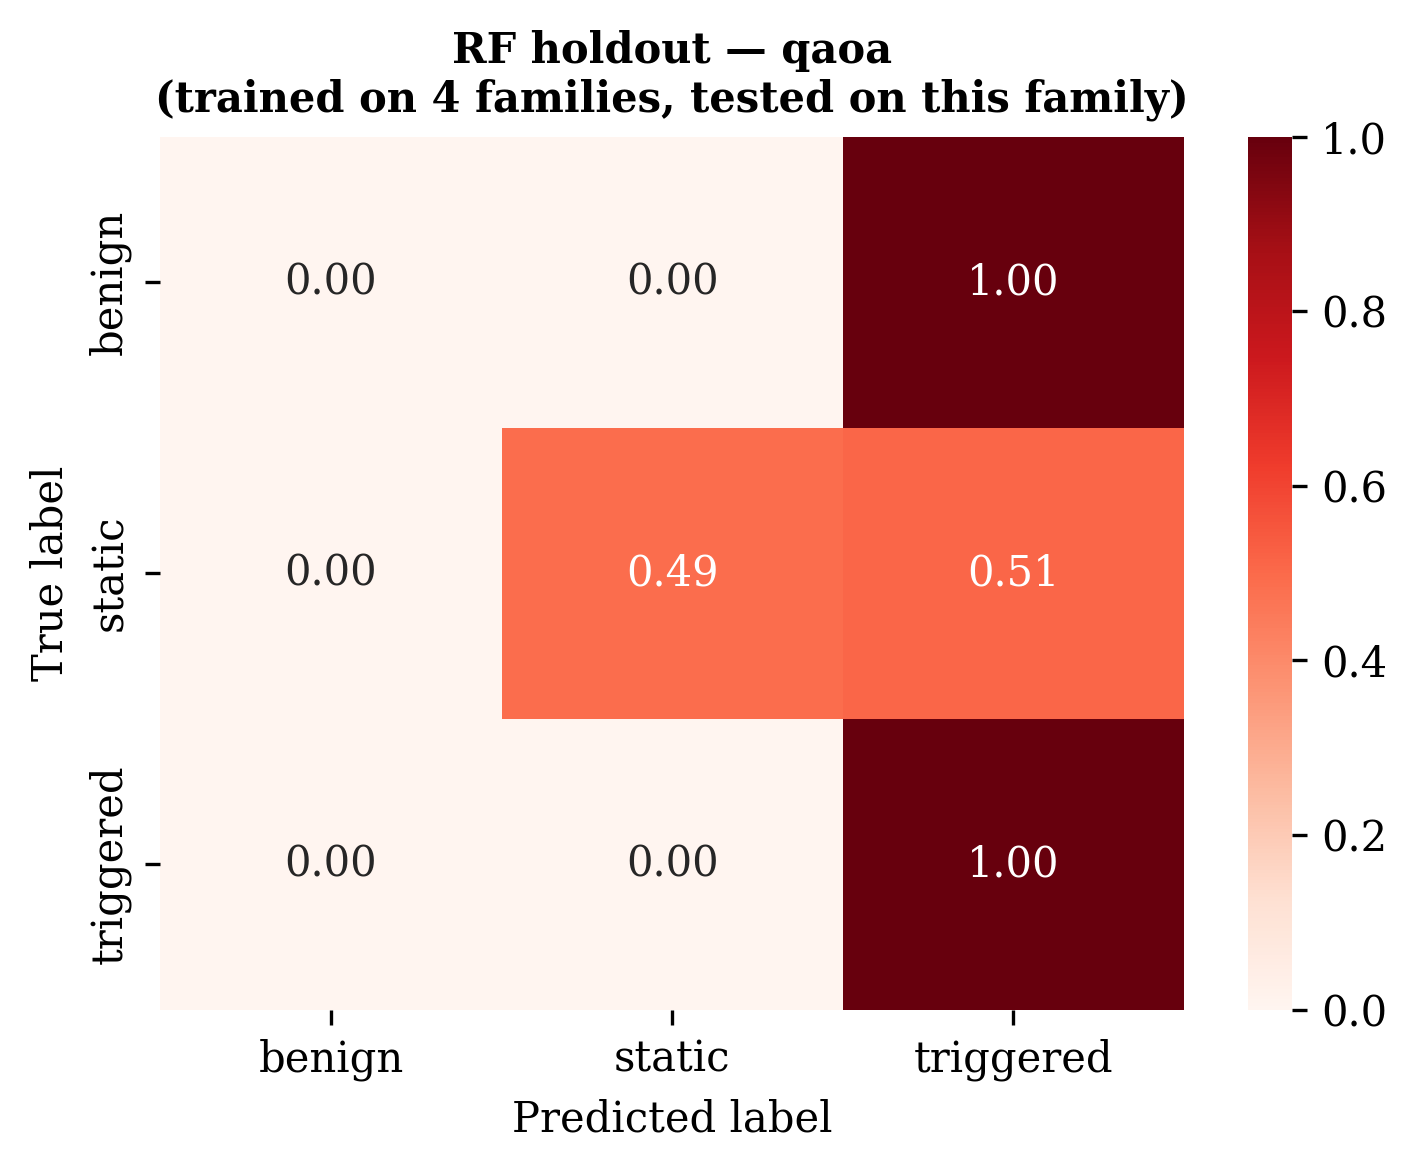

Saved: holdout_confusion_qaoa.png / .pdf


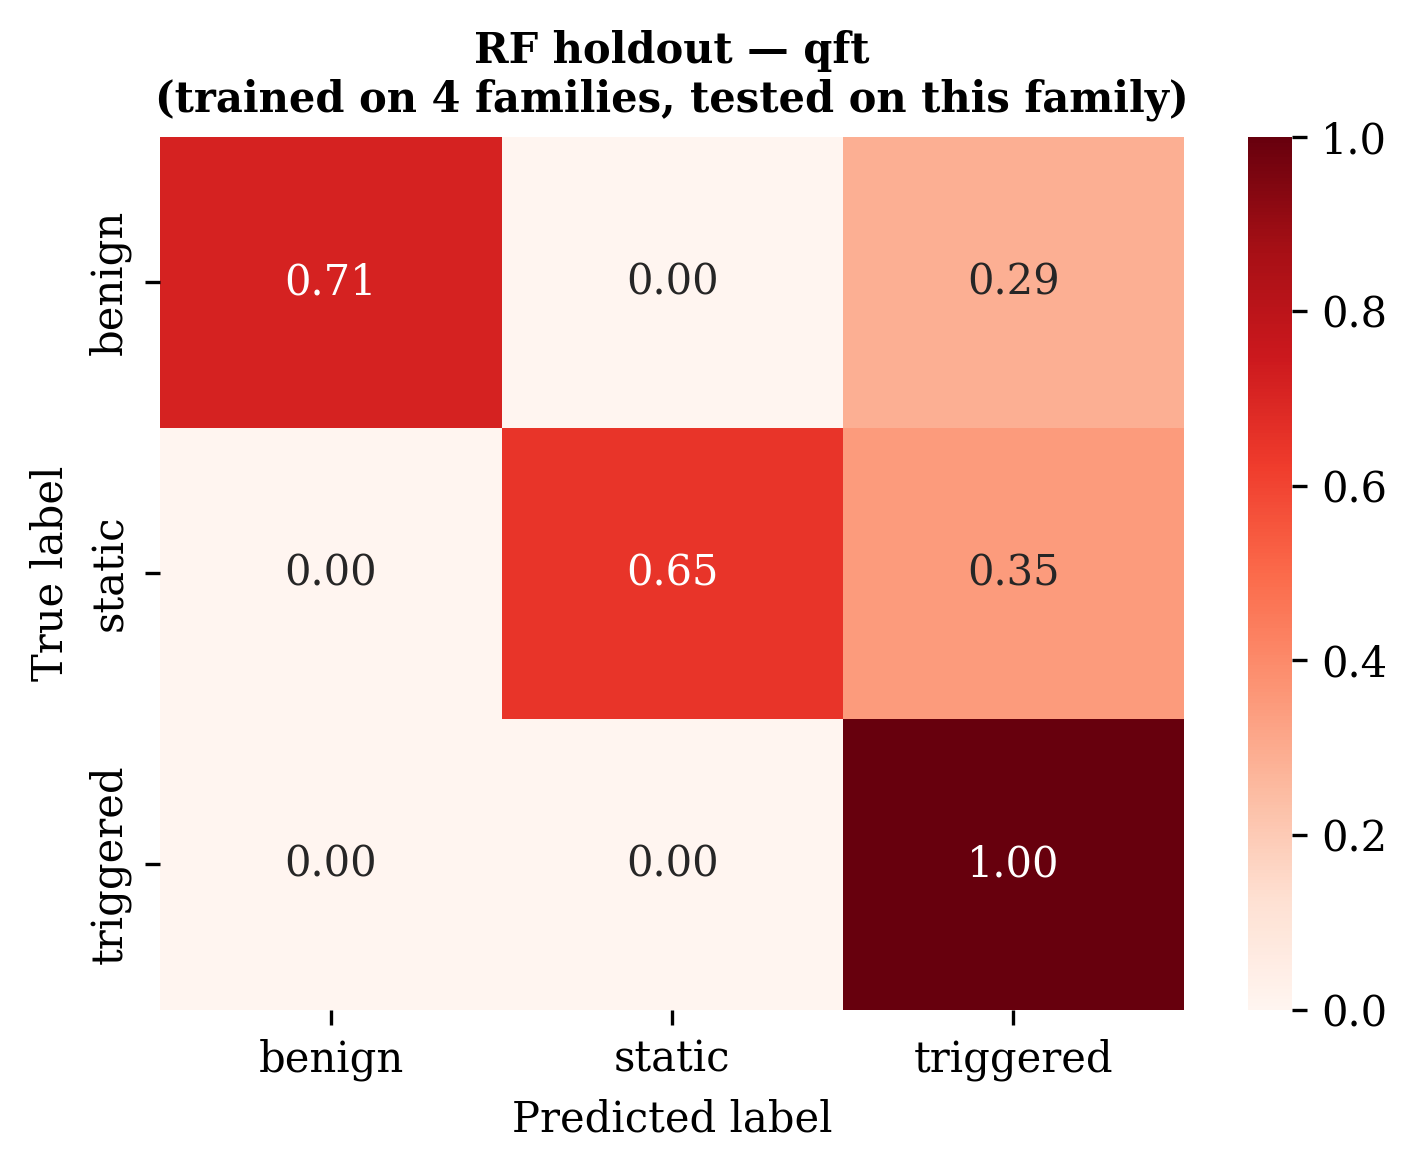

Saved: holdout_confusion_qft.png / .pdf


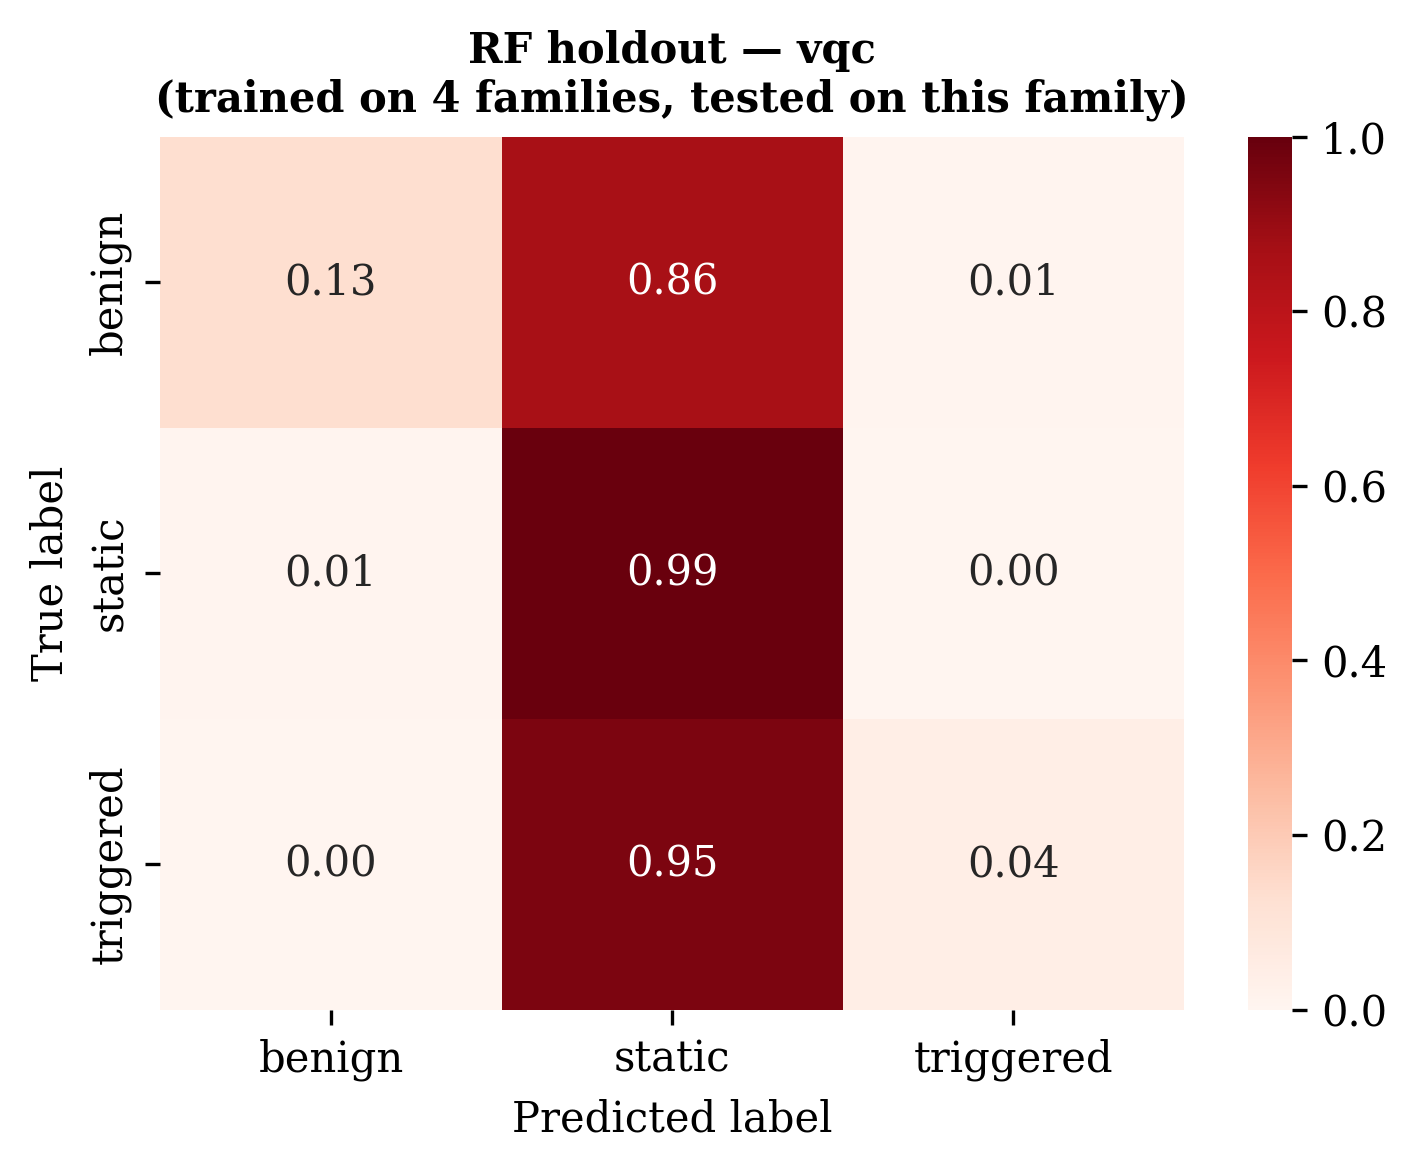

Saved: holdout_confusion_vqc.png / .pdf

Cell 4 complete — Experiment B done.


In [12]:
# ============================================================
# CELL 4 — Experiment B: Leave-One-Family-Out Holdout
# ============================================================
#
# Protocol:
#   5 rounds. Each round holds out one algorithm family.
#   Models trained on remaining 4 families (7,200 circuits).
#   Tested on held-out family (1,800 circuits).
#   No data from held-out family appears in training.
#
# Per held-out family reports:
#   - Overall balanced accuracy and F1-macro
#   - Per-class recall (benign / static / triggered)
#   - Confusion matrix heatmap
#
# Statistical test:
#   Friedman test across holdout balanced accuracies
#   to determine whether performance differs significantly
#   across families.
#
# Outputs:
#   results/exp_holdout/holdout_summary.csv
#   results/exp_holdout/holdout_bar_chart.png/.pdf
#   results/exp_holdout/holdout_confusion_{family}.png/.pdf
#   results/exp_holdout/friedman_test.json
#
# Expected time: 5-10 minutes
# ============================================================

HOLDOUT_DIR = RESULTS_DIR / "exp_holdout"

holdout_results = []   # one dict per family per model
holdout_preds   = defaultdict(list)  # model → [(y_true, y_pred)]

print("=" * 55)
print("Experiment B — Leave-One-Family-Out Holdout")
print("=" * 55)

for holdout_family in FAMILIES:

    train_mask = df["algorithm_family"] != holdout_family
    test_mask  = df["algorithm_family"] == holdout_family

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]
    X_test  = X_all[test_mask]
    y_test  = y_all[test_mask]

    print(f"\n  Holdout: {holdout_family}")
    print(f"    Train: {X_train.shape[0]} circuits")
    print(f"    Test : {X_test.shape[0]} circuits")

    for model_name, model in make_models().items():

        result = evaluate(
            model, X_train, y_train, X_test, y_test
        )

        y_pred = result["y_pred"]

        # Per-class recall
        cm = confusion_matrix(
            y_test, y_pred, labels=CLASS_LABELS
        )
        per_class_recall = {}
        for i, cls in enumerate(CLASS_ORDER):
            row_sum = cm[i].sum()
            per_class_recall[f"recall_{cls}"] = (
                float(cm[i, i] / row_sum) if row_sum > 0 else 0.0
            )

        holdout_results.append({
            "holdout_family":   holdout_family,
            "model":            model_name,
            "balanced_accuracy": result["balanced_accuracy"],
            "f1_macro":          result["f1_macro"],
            "roc_auc_ovr":       result["roc_auc_ovr"],
            **per_class_recall,
        })

        holdout_preds[model_name].append(
            (y_test, y_pred)
        )

        print(
            f"    {model_name:15s} — "
            f"bal_acc={result['balanced_accuracy']:.3f}  "
            f"f1={result['f1_macro']:.3f}  "
            f"recall: "
            f"benign={per_class_recall['recall_benign']:.2f}  "
            f"static={per_class_recall['recall_static']:.2f}  "
            f"triggered={per_class_recall['recall_triggered']:.2f}"
        )

# ── Save summary CSV ──────────────────────────────────────────

holdout_df = pd.DataFrame(holdout_results)
holdout_df.to_csv(
    HOLDOUT_DIR / "holdout_summary.csv", index=False
)
print(f"\nSaved: holdout_summary.csv")

# ── Print summary table ───────────────────────────────────────

print("\n" + "=" * 55)
print("Holdout Results Summary")
print("=" * 55)
print(f"{'Family':<20} {'Model':<16} "
      f"{'Bal.Acc':>8} {'F1':>8}")
print("-" * 55)

for row in holdout_results:
    print(
        f"  {row['holdout_family']:<18} "
        f"{row['model']:<16} "
        f"{row['balanced_accuracy']:>8.3f} "
        f"{row['f1_macro']:>8.3f}"
    )

# ── Friedman test ─────────────────────────────────────────────
# Tests whether holdout balanced accuracy differs significantly
# across the 5 families for each model

print("\nFriedman test — holdout balanced accuracy across families")

friedman_results = {}

for model_name in make_models():
    model_rows = [
        r for r in holdout_results
        if r["model"] == model_name
    ]
    scores = [r["balanced_accuracy"] for r in model_rows]

    # Friedman requires groups — use per-family scores
    # Here we have one score per family so we use
    # the scores directly as the 5 conditions
    if len(scores) >= 3:
        # Reshape for Friedman: treat each family as a block
        stat, p = friedmanchisquare(*[
            [r["balanced_accuracy"]]
            for r in model_rows
        ])
    else:
        stat, p = 0.0, 1.0

    friedman_results[model_name] = {
        "statistic": float(stat),
        "p_value":   float(p),
    }
    print(f"  {model_name:15s} — "
          f"stat={stat:.4f}  p={p:.4f}")

with open(HOLDOUT_DIR / "friedman_test.json", "w") as f:
    json.dump(friedman_results, f, indent=2)
print("Saved: friedman_test.json")

# ── Bar chart: IID vs holdout per family ──────────────────────

iid_rf_mean = np.mean(iid_results["random_forest"]["balanced_accuracy"])

rf_holdout = [
    r for r in holdout_results
    if r["model"] == "random_forest"
]
rf_holdout_sorted = sorted(
    rf_holdout, key=lambda r: r["holdout_family"]
)

families_sorted = [r["holdout_family"] for r in rf_holdout_sorted]
holdout_scores  = [r["balanced_accuracy"]
                   for r in rf_holdout_sorted]

x     = np.arange(len(families_sorted))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width/2, [iid_rf_mean] * len(families_sorted),
    width, label=f"IID (mean={iid_rf_mean:.3f})",
    color="#1565C0", alpha=0.8, edgecolor="white",
)
ax.bar(
    x + width/2, holdout_scores,
    width, label="Holdout",
    color="#C62828", alpha=0.8, edgecolor="white",
)

ax.axhline(
    1/3, color="black", linestyle="--",
    linewidth=1, label="Random baseline (3-class)",
)
ax.set_xticks(x)
ax.set_xticklabels(
    [f.replace("_", "\n") for f in families_sorted],
    fontsize=9,
)
ax.set_ylabel("Balanced Accuracy", fontsize=11)
ax.set_ylim(0.0, 1.05)
ax.set_title(
    "Random Forest: IID vs leave-one-family-out holdout\n"
    "(three-class: benign / static / triggered)",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(
    HOLDOUT_DIR / "holdout_bar_chart.png",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    HOLDOUT_DIR / "holdout_bar_chart.pdf",
    dpi=300, bbox_inches="tight",
)
plt.show()
print("Saved: holdout_bar_chart.png / .pdf")

# ── Per-family confusion heatmaps (RF only) ───────────────────

rf_holdout_preds = holdout_preds["random_forest"]

for i, holdout_family in enumerate(FAMILIES):
    y_true_h, y_pred_h = rf_holdout_preds[i]

    cm_h      = confusion_matrix(
        y_true_h, y_pred_h, labels=CLASS_LABELS
    )
    cm_h_norm = cm_h.astype(float) / \
        cm_h.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm_h_norm, annot=True, fmt=".2f", cmap="Reds",
        xticklabels=CLASS_ORDER,
        yticklabels=CLASS_ORDER,
        ax=ax,
        vmin=0.0, vmax=1.0,
    )
    ax.set_ylabel("True label", fontsize=10)
    ax.set_xlabel("Predicted label", fontsize=10)
    ax.set_title(
        f"RF holdout — {holdout_family.replace('_', ' ')}\n"
        f"(trained on 4 families, tested on this family)",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout()

    fig.savefig(
        HOLDOUT_DIR / f"holdout_confusion_{holdout_family}.png",
        dpi=300, bbox_inches="tight",
    )
    fig.savefig(
        HOLDOUT_DIR / f"holdout_confusion_{holdout_family}.pdf",
        dpi=300, bbox_inches="tight",
    )
    plt.show()
    plt.close(fig)
    print(f"Saved: holdout_confusion_{holdout_family}.png / .pdf")

print("\nCell 4 complete — Experiment B done.")

Computing RF feature importances on full dataset...

Top 5 features by RF importance:
  1. logical_cx_ratio                              0.265633
  2. logical_degree_std_over_mean                  0.132809
  3. logical_frac_interactions_top1                0.054156
  4. logical_max_edge_weight_over_total            0.053705
  5. logical_max_degree_norm                       0.049340

Saved: rf_feature_importance.csv


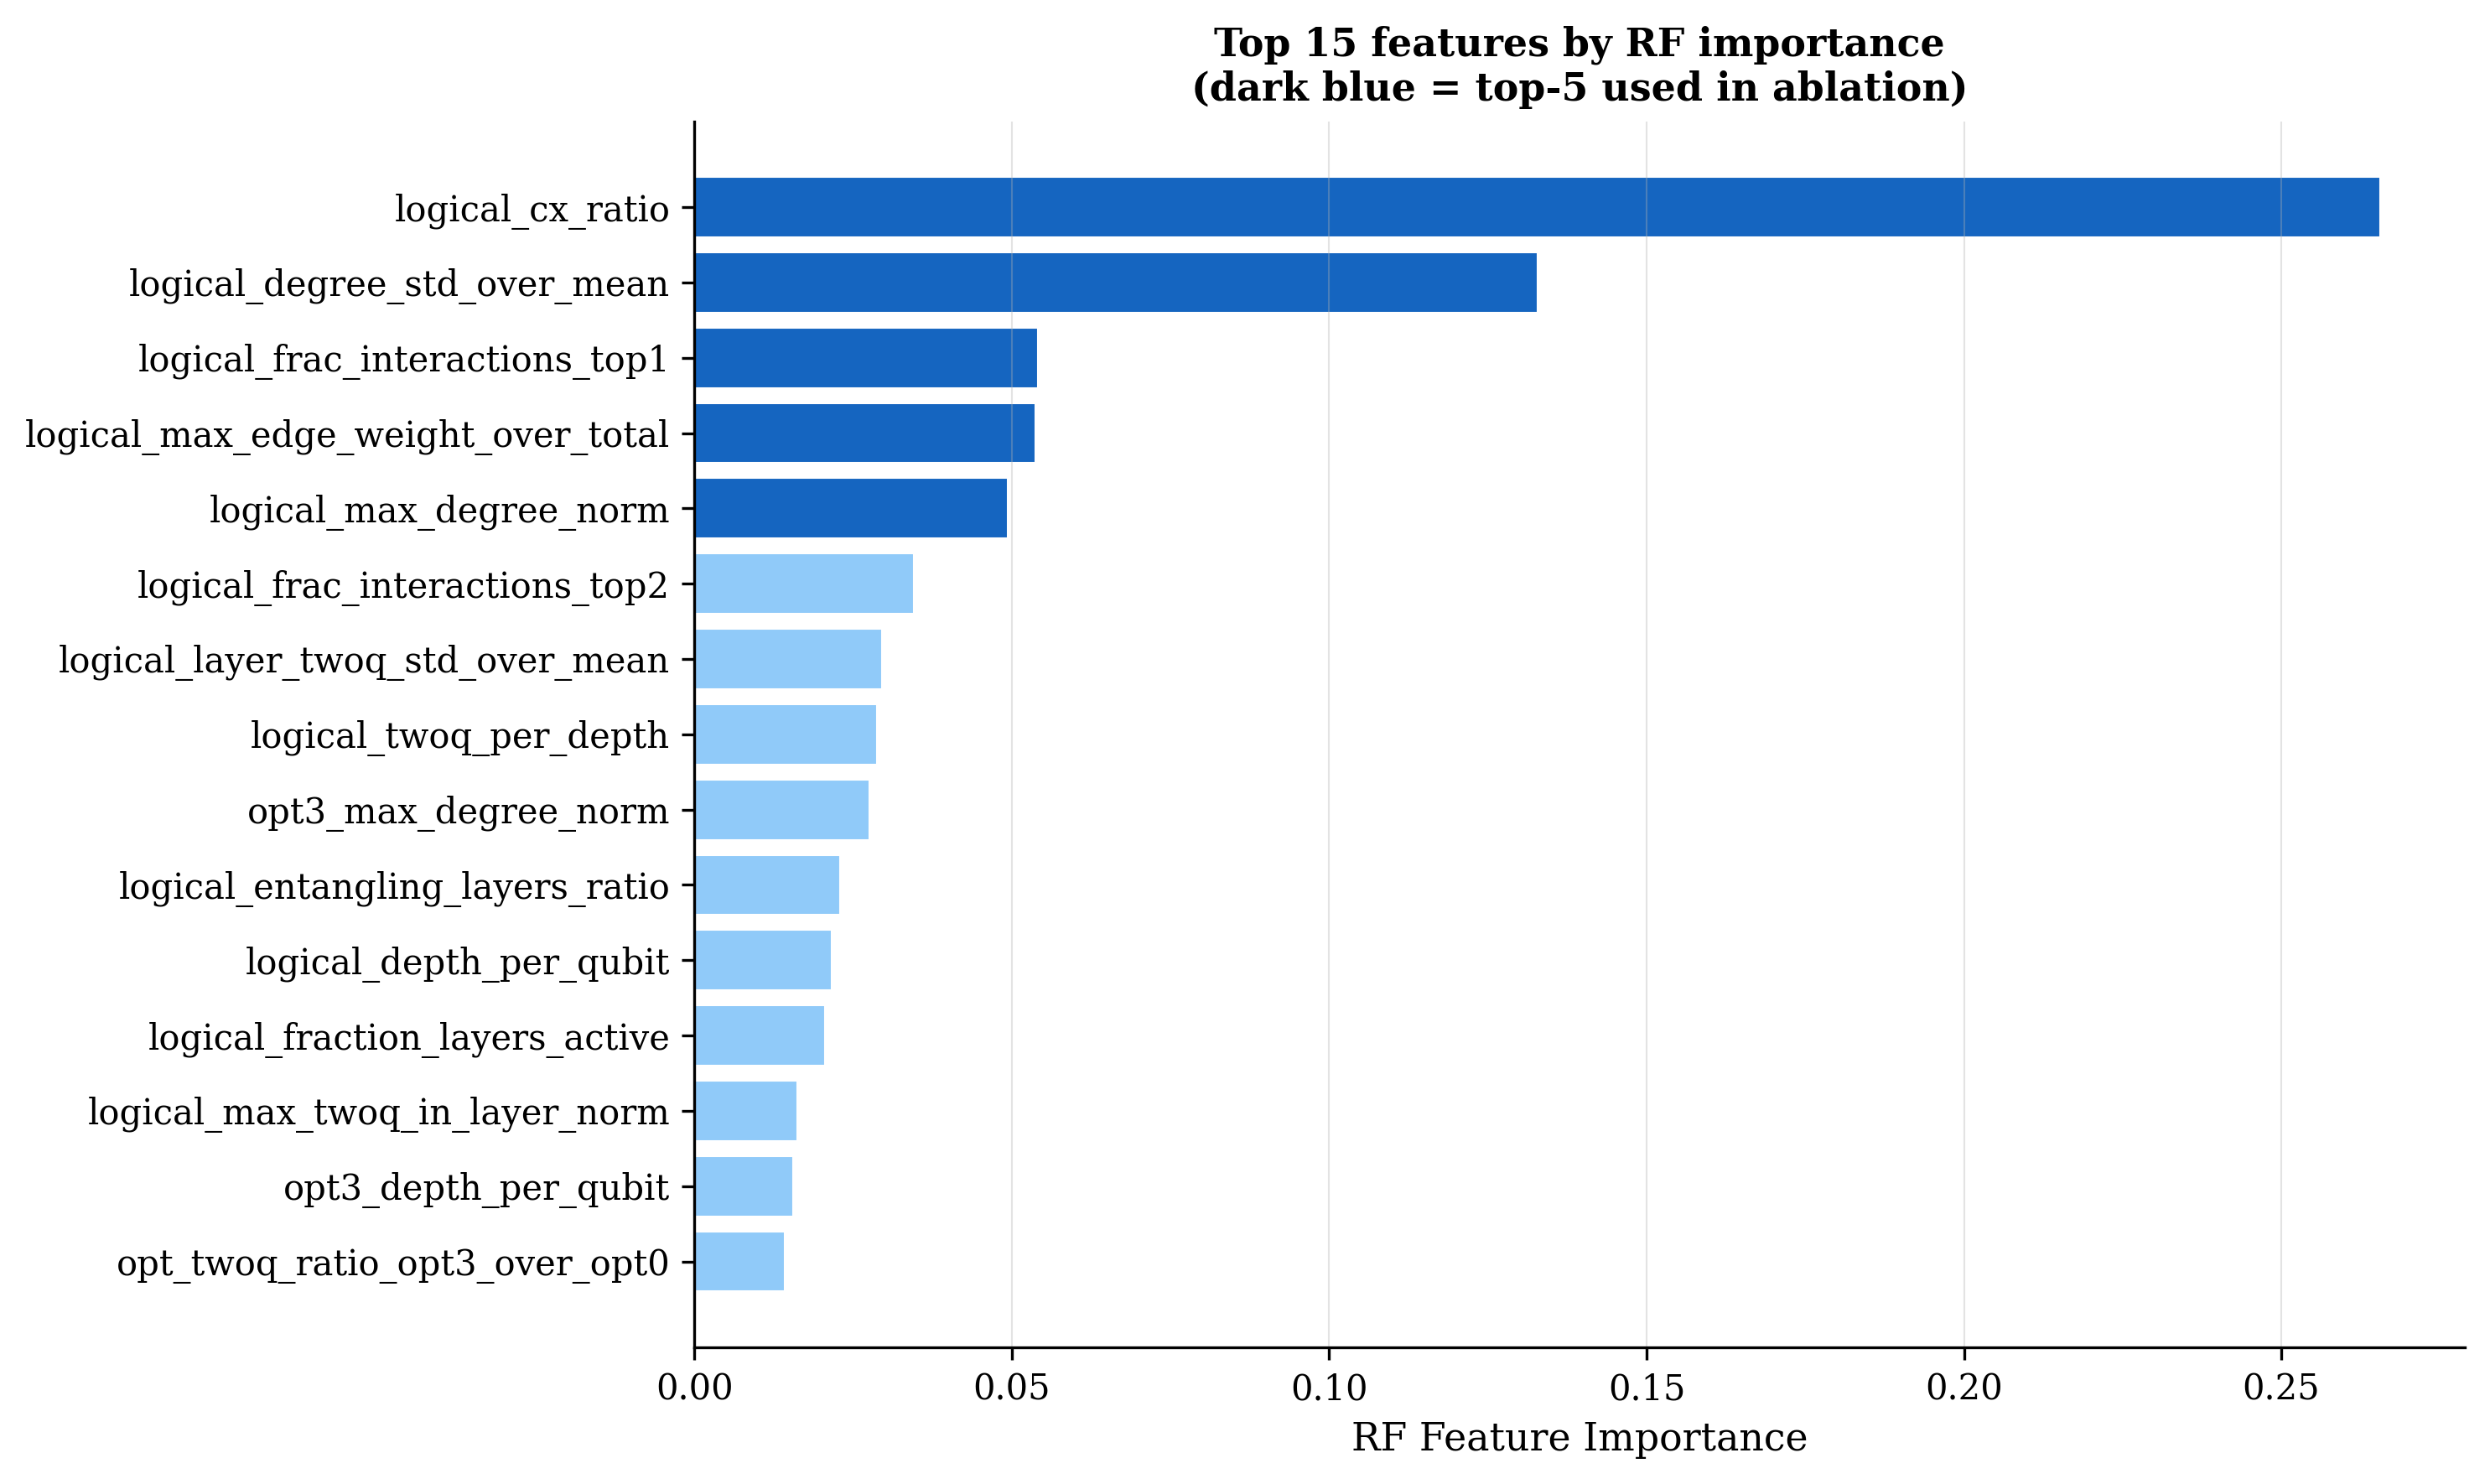

Saved: rf_feature_importance.png / .pdf

Ablation conditions:
  full_39    : 39 features
  top_5      : 5 features
             logical_cx_ratio
             logical_degree_std_over_mean
             logical_frac_interactions_top1
             logical_max_edge_weight_over_total
             logical_max_degree_norm
  naive_3    : 3 features
             logical_depth_per_qubit
             logical_twoq_per_depth
             logical_cx_ratio

Running ablation CV (45 total fits)...
-------------------------------------------------------
  [  5/45] full_39    repeat=0 fold=4 — bal_acc=0.952
  [ 10/45] full_39    repeat=1 fold=4 — bal_acc=0.952
  [ 15/45] full_39    repeat=2 fold=4 — bal_acc=0.951
  [ 20/45] top_5      repeat=0 fold=4 — bal_acc=0.968
  [ 25/45] top_5      repeat=1 fold=4 — bal_acc=0.955
  [ 30/45] top_5      repeat=2 fold=4 — bal_acc=0.957
  [ 35/45] naive_3    repeat=0 fold=4 — bal_acc=0.921
  [ 40/45] naive_3    repeat=1 fold=4 — bal_acc=0.929
  [ 45/45] naive_3    repea

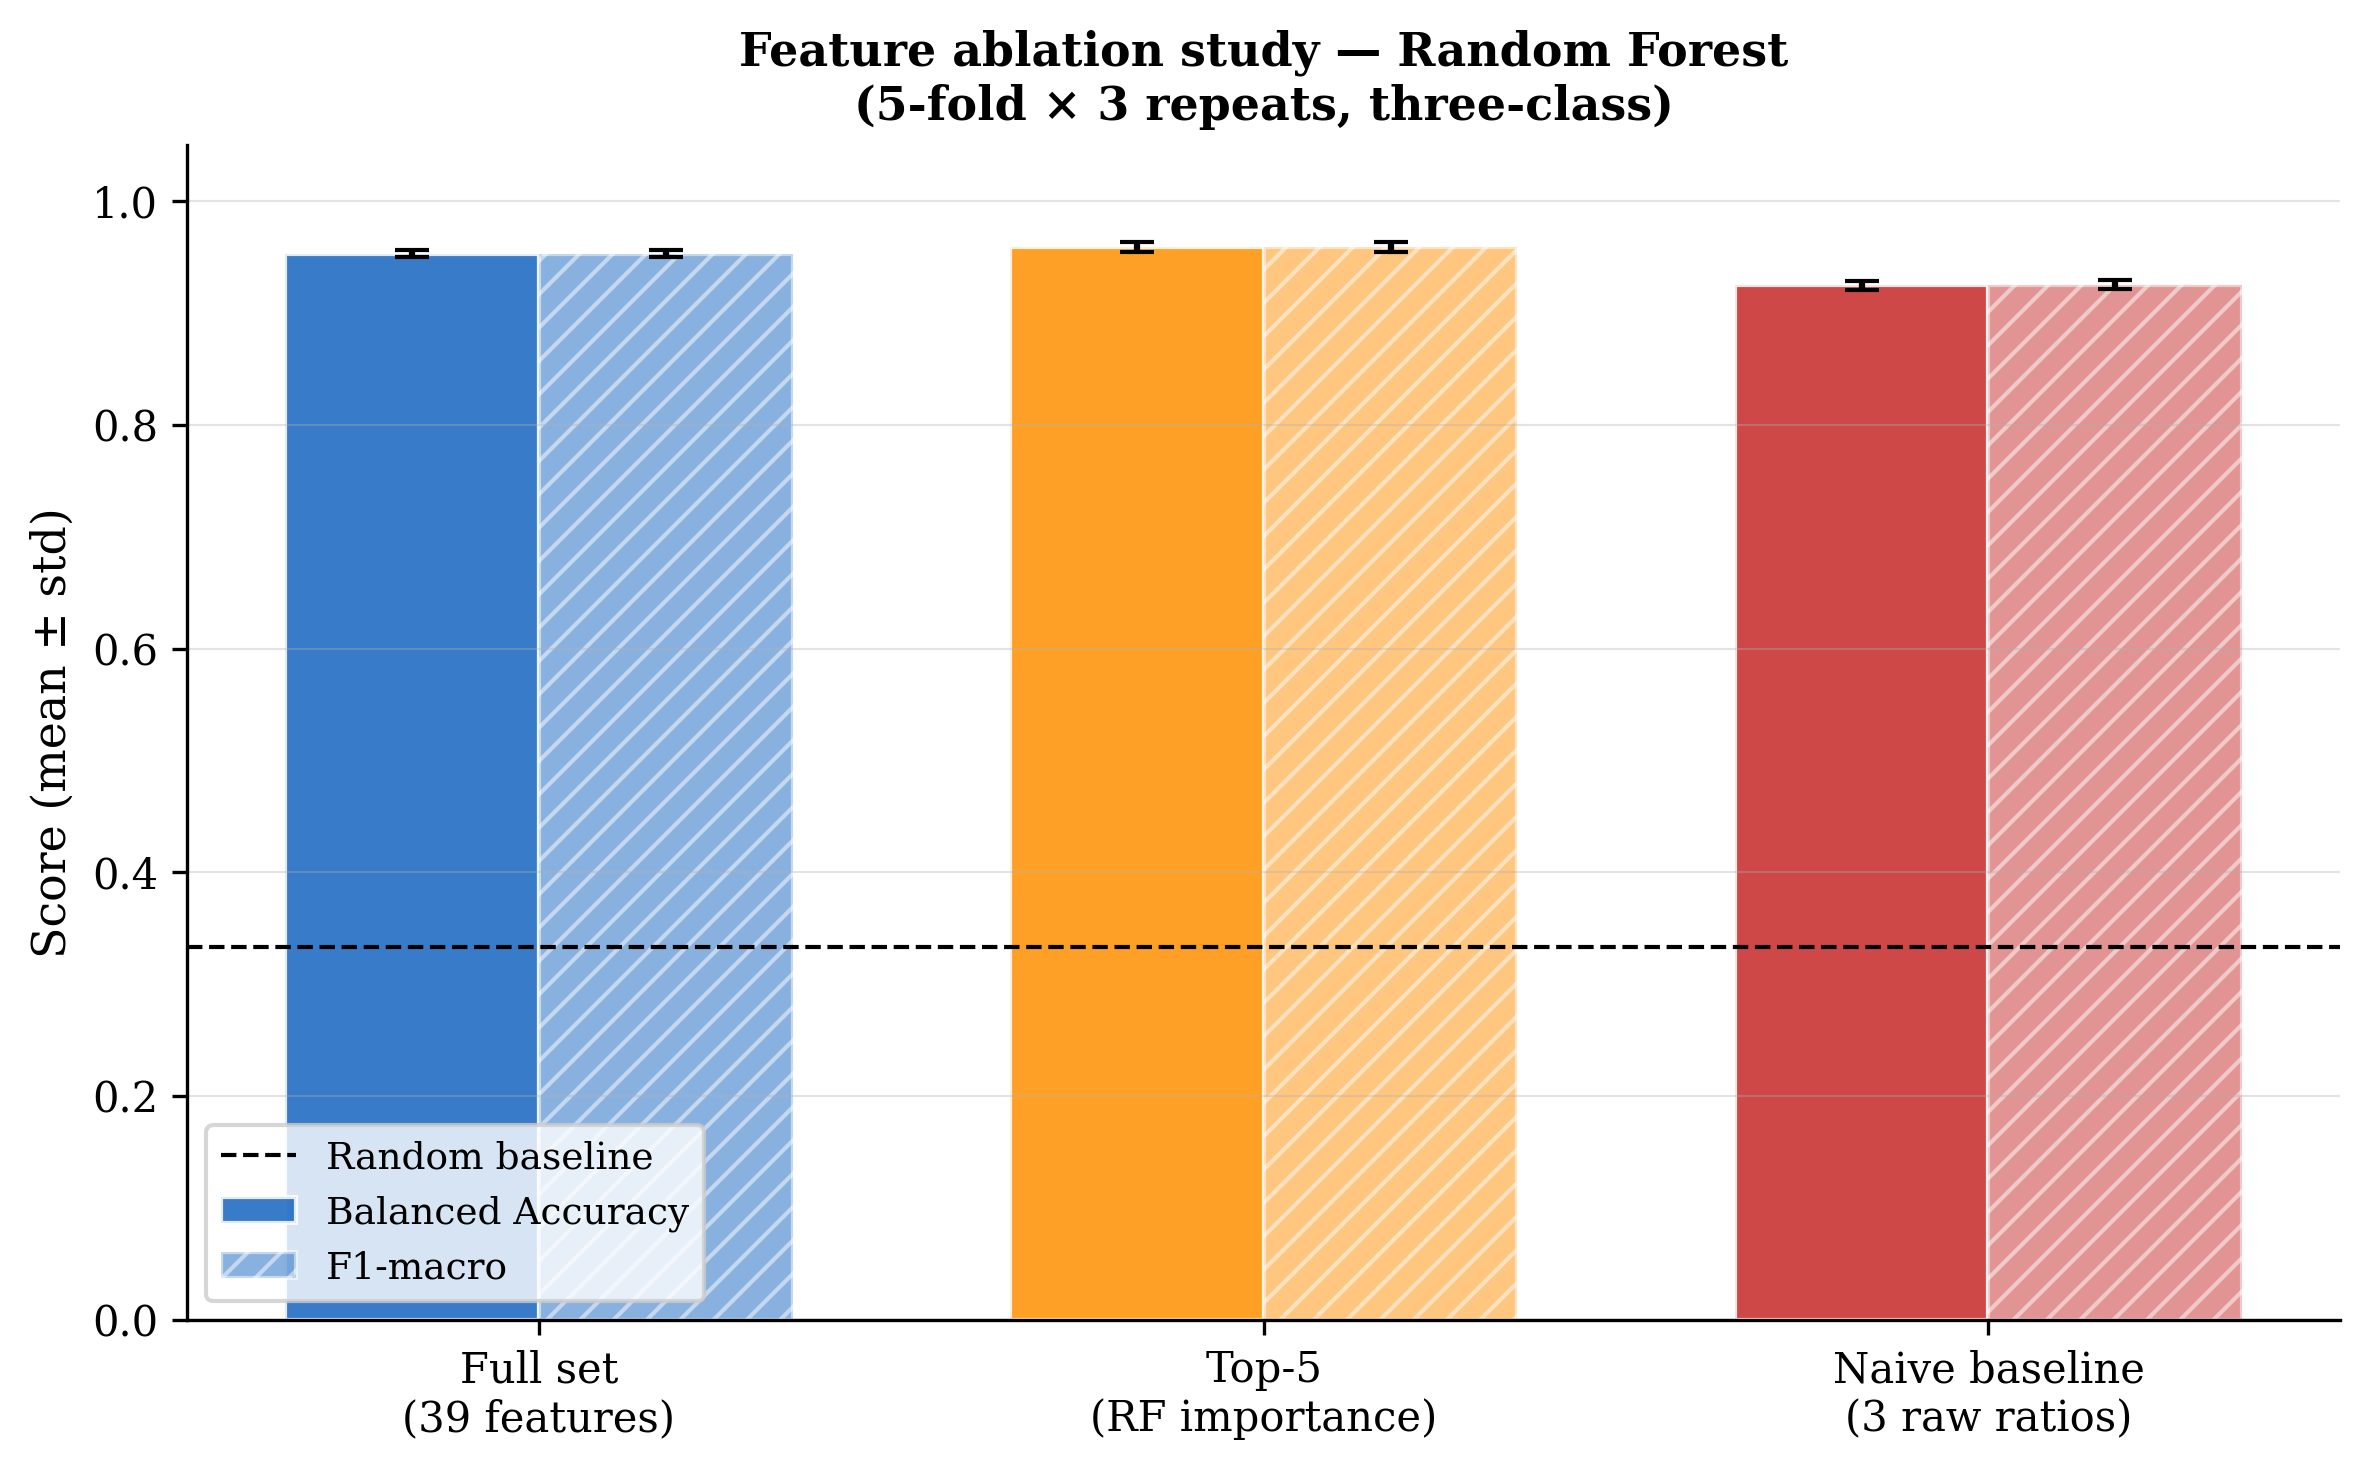

Saved: ablation_bar_chart.png / .pdf

Cell 5 complete — Experiment C done.


In [13]:
# ============================================================
# CELL 5 — Experiment C: Feature Ablation Study
# ============================================================
#
# Purpose:
#   Prove that the full normalised feature set adds value
#   over simpler alternatives. Three conditions compared:
#
#   1. Full set    : all 39 normalised features (our approach)
#   2. Top-5       : five highest RF importance features
#   3. Naive       : 3 raw features requiring no engineering
#                    (depth_per_qubit, twoq_per_depth, cx_ratio
#                     from logical representation only)
#
# Protocol:
#   Random Forest only (ablation does not need all models).
#   Same 5-fold × 3 repeats as Experiment A.
#   Source-circuit stratified splits (same split_index.csv).
#
# The naive baseline answers the reviewer question:
#   "Would any three features work just as well?"
#
# Outputs:
#   results/exp_ablation/ablation_summary.csv
#   results/exp_ablation/ablation_bar_chart.png/.pdf
#   results/exp_ablation/rf_feature_importance.csv
#   results/exp_ablation/rf_feature_importance.png/.pdf
#
# Expected time: 5-10 minutes
# ============================================================

ABLATION_DIR = RESULTS_DIR / "exp_ablation"

# ── Step 1: Get RF feature importances from full IID run ──────
# Train RF on full dataset to get stable importances

print("Computing RF feature importances on full dataset...")

rf_full = copy.deepcopy(make_models()["random_forest"])
rf_full.fit(X_all, y_all)

importances = rf_full.feature_importances_
idx_sorted  = np.argsort(importances)[::-1]

# Top-5 feature names and indices
TOP_K       = 5
top5_names  = [FEATURE_COLS[i] for i in idx_sorted[:TOP_K]]
top5_idx    = idx_sorted[:TOP_K]

print(f"\nTop {TOP_K} features by RF importance:")
for rank, i in enumerate(idx_sorted[:TOP_K]):
    print(f"  {rank+1}. {FEATURE_COLS[i]:<45s} "
          f"{importances[i]:.6f}")

# Save full importance ranking
importance_rows = [
    {
        "rank":       rank + 1,
        "feature":    FEATURE_COLS[i],
        "importance": float(importances[i]),
    }
    for rank, i in enumerate(idx_sorted)
]
importance_df = pd.DataFrame(importance_rows)
importance_df.to_csv(
    ABLATION_DIR / "rf_feature_importance.csv", index=False
)
print(f"\nSaved: rf_feature_importance.csv")

# ── Feature importance bar chart ──────────────────────────────

TOP_PLOT = 15
fig, ax  = plt.subplots(figsize=(10, 6))

names_plot = [FEATURE_COLS[i] for i in idx_sorted[:TOP_PLOT]]
vals_plot  = [importances[i]   for i in idx_sorted[:TOP_PLOT]]

colors_plot = [
    "#1565C0" if n in top5_names else "#90CAF9"
    for n in names_plot
]

ax.barh(
    names_plot[::-1], vals_plot[::-1],
    color=colors_plot[::-1],
    edgecolor="white", linewidth=0.5,
)
ax.set_xlabel("RF Feature Importance", fontsize=11)
ax.set_title(
    f"Top {TOP_PLOT} features by RF importance\n"
    f"(dark blue = top-5 used in ablation)",
    fontsize=11, fontweight="bold",
)
ax.grid(axis="x", alpha=0.35, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

fig.savefig(
    ABLATION_DIR / "rf_feature_importance.png",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    ABLATION_DIR / "rf_feature_importance.pdf",
    dpi=300, bbox_inches="tight",
)
plt.show()
print("Saved: rf_feature_importance.png / .pdf")

# ── Step 2: Define three feature conditions ───────────────────

# Naive baseline: 3 structural ratios from logical rep only
# These require no topology or layer analysis
NAIVE_FEATURES = [
    "logical_depth_per_qubit",
    "logical_twoq_per_depth",
    "logical_cx_ratio",
]
naive_idx = [FEATURE_COLS.index(f) for f in NAIVE_FEATURES]

CONDITIONS = {
    "full_39":  np.arange(len(FEATURE_COLS)),  # all 39
    "top_5":    top5_idx,                       # top 5 by RF
    "naive_3":  np.array(naive_idx),            # 3 raw ratios
}

print(f"\nAblation conditions:")
for name, idx in CONDITIONS.items():
    print(f"  {name:10s} : {len(idx)} features")
    if name != "full_39":
        for i in idx:
            print(f"             {FEATURE_COLS[i]}")

# ── Step 3: Run ablation CV ───────────────────────────────────

ablation_results = {
    cond: defaultdict(list) for cond in CONDITIONS
}

total_fits = len(CONDITIONS) * N_REPEATS * N_FOLDS
fit_count  = 0

print(f"\nRunning ablation CV ({total_fits} total fits)...")
print("-" * 55)

for cond_name, feat_idx in CONDITIONS.items():
    X_cond = X_all[:, feat_idx]

    for repeat in range(N_REPEATS):
        fold_col = f"fold_iid_r{repeat}"

        for fold in range(N_FOLDS):
            train_mask = df[fold_col] != fold
            test_mask  = df[fold_col] == fold

            X_train = X_cond[train_mask]
            y_train = y_all[train_mask]
            X_test  = X_cond[test_mask]
            y_test  = y_all[test_mask]

            result = evaluate(
                make_models()["random_forest"],
                X_train, y_train,
                X_test,  y_test,
            )

            ablation_results[cond_name][
                "balanced_accuracy"
            ].append(result["balanced_accuracy"])

            ablation_results[cond_name][
                "f1_macro"
            ].append(result["f1_macro"])

            fit_count += 1
            if fit_count % 5 == 0:
                print(
                    f"  [{fit_count:3d}/{total_fits}] "
                    f"{cond_name:10s} "
                    f"repeat={repeat} fold={fold} — "
                    f"bal_acc="
                    f"{result['balanced_accuracy']:.3f}"
                )

# ── Summary ───────────────────────────────────────────────────

print("\n" + "=" * 55)
print("Ablation Results Summary (RF, mean ± std)")
print("=" * 55)
print(f"{'Condition':<12} {'N feats':>8} "
      f"{'Bal.Acc':>12} {'F1-macro':>12}")
print("-" * 55)

ablation_rows = []
n_feats_map = {
    "full_39": 39,
    "top_5":   5,
    "naive_3": 3,
}

for cond_name in CONDITIONS:
    r        = ablation_results[cond_name]
    bal_mean = np.mean(r["balanced_accuracy"])
    bal_std  = np.std(r["balanced_accuracy"])
    f1_mean  = np.mean(r["f1_macro"])
    f1_std   = np.std(r["f1_macro"])
    n_feats  = n_feats_map[cond_name]

    print(
        f"  {cond_name:<10} {n_feats:>8}  "
        f"{bal_mean:.3f}±{bal_std:.3f}  "
        f"{f1_mean:.3f}±{f1_std:.3f}"
    )

    ablation_rows.append({
        "condition":        cond_name,
        "n_features":       n_feats,
        "bal_acc_mean":     round(bal_mean, 4),
        "bal_acc_std":      round(bal_std,  4),
        "f1_macro_mean":    round(f1_mean,  4),
        "f1_macro_std":     round(f1_std,   4),
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(
    ABLATION_DIR / "ablation_summary.csv", index=False
)
print(f"\nSaved: ablation_summary.csv")

# ── Bar chart ─────────────────────────────────────────────────

cond_labels = {
    "full_39": "Full set\n(39 features)",
    "top_5":   "Top-5\n(RF importance)",
    "naive_3": "Naive baseline\n(3 raw ratios)",
}
bar_colors = ["#1565C0", "#FF8F00", "#C62828"]

fig, ax = plt.subplots(figsize=(8, 5))

x      = np.arange(len(CONDITIONS))
width  = 0.35
conds  = list(CONDITIONS.keys())

bal_means = [
    np.mean(ablation_results[c]["balanced_accuracy"])
    for c in conds
]
bal_stds = [
    np.std(ablation_results[c]["balanced_accuracy"])
    for c in conds
]
f1_means = [
    np.mean(ablation_results[c]["f1_macro"])
    for c in conds
]
f1_stds = [
    np.std(ablation_results[c]["f1_macro"])
    for c in conds
]

bars1 = ax.bar(
    x - width/2, bal_means, width,
    yerr=bal_stds, capsize=4,
    label="Balanced Accuracy",
    color=bar_colors,
    alpha=0.85, edgecolor="white",
)
bars2 = ax.bar(
    x + width/2, f1_means, width,
    yerr=f1_stds, capsize=4,
    label="F1-macro",
    color=bar_colors,
    alpha=0.50, edgecolor="white",
    hatch="///",
)

ax.axhline(
    1/3, color="black", linestyle="--",
    linewidth=1, label="Random baseline",
)
ax.set_xticks(x)
ax.set_xticklabels(
    [cond_labels[c] for c in conds], fontsize=10
)
ax.set_ylabel("Score (mean ± std)", fontsize=11)
ax.set_ylim(0.0, 1.05)
ax.set_title(
    "Feature ablation study — Random Forest\n"
    "(5-fold × 3 repeats, three-class)",
    fontsize=11, fontweight="bold",
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35, linewidth=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
fig.savefig(
    ABLATION_DIR / "ablation_bar_chart.png",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    ABLATION_DIR / "ablation_bar_chart.pdf",
    dpi=300, bbox_inches="tight",
)
plt.show()
print("Saved: ablation_bar_chart.png / .pdf")

print("\nCell 5 complete — Experiment C done.")


Experiment D — Trojan Type Analysis

Per-class performance (aggregated over 15 folds):

Model            Class         Precision     Recall         F1
--------------------------------------------------------------
  random_forest  benign            0.932      0.927      0.929
  random_forest  static            1.000      0.998      0.999
  random_forest  triggered         0.927      0.934      0.931

  linear_svm     benign            0.738      0.860      0.795
  linear_svm     static            0.787      0.698      0.740
  linear_svm     triggered         0.663      0.629      0.646

  rbf_svm        benign            0.815      0.761      0.787
  rbf_svm        static            0.746      0.794      0.769
  rbf_svm        triggered         0.691      0.693      0.692

Saved: trojan_type_summary.csv


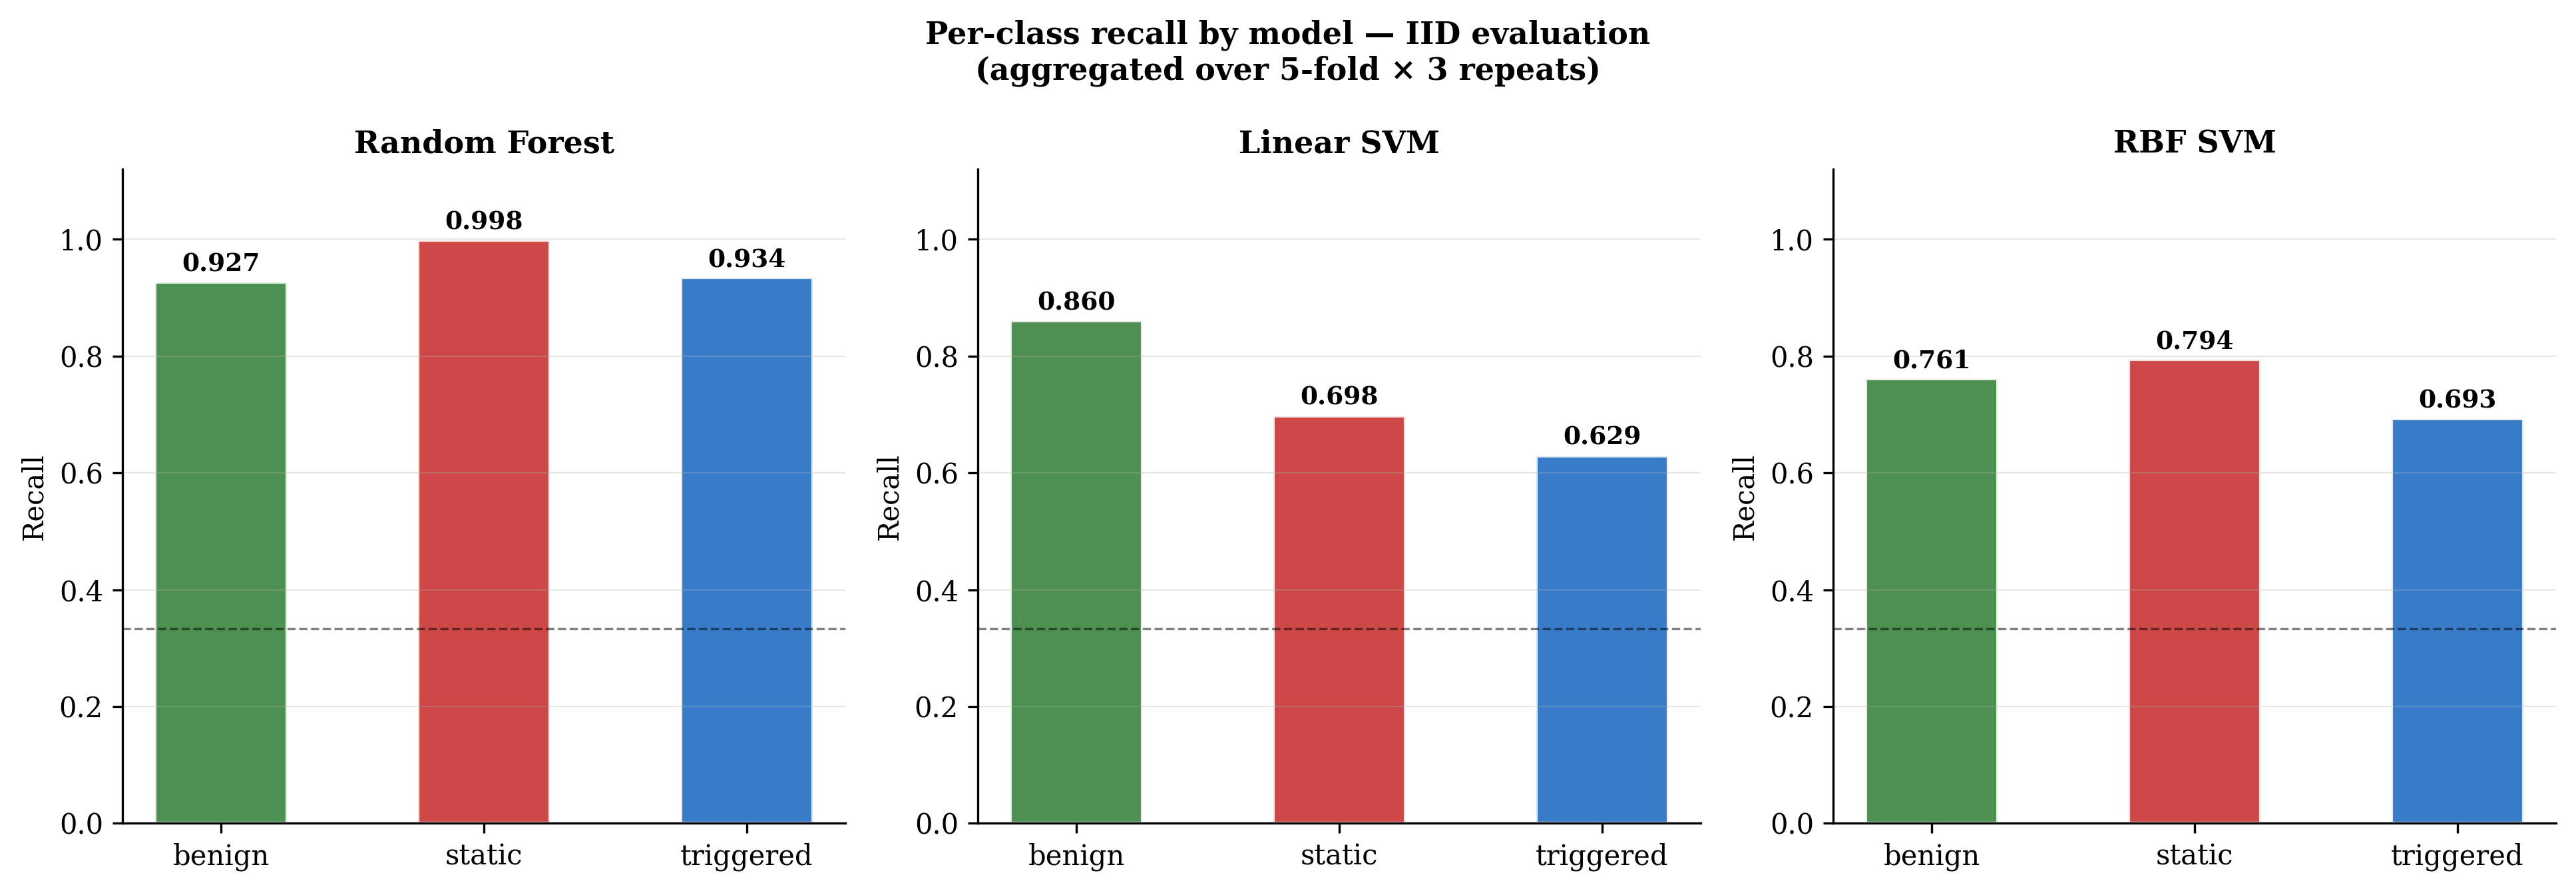

Saved: trojan_type_recall_chart.png / .pdf

Per-family per-class recall (RF, last fold):
Family                 Benign   Static  Triggered
--------------------------------------------------
  deutsch_jozsa         1.000    1.000      1.000
  grover                1.000    1.000      1.000
  qaoa                  0.913    1.000      0.943
  qft                   1.000    1.000      1.000
  vqc                   0.997    0.998      1.000

Saved: trojan_type_per_family.csv

RQ2 Summary — Static vs Triggered Detectability
  random_forest    static=0.998  triggered=0.934  gap=+0.064
  linear_svm       static=0.698  triggered=0.629  gap=+0.069
  rbf_svm          static=0.794  triggered=0.693  gap=+0.101

Cell 6 complete — Experiment D done.

S5 complete. All four experiments finished.
Ready for S6 — QSVM baseline.


In [14]:
# ============================================================
# CELL 6 — Experiment D: Trojan Type Analysis
# ============================================================
#
# Purpose:
#   Analyse whether static and triggered Trojans have
#   different structural detectability under IID conditions.
#
#   This directly addresses RQ2:
#   "Do static and triggered Trojan variants exhibit
#    different detection rates under structure-based ML?"
#
# Uses predictions already computed in Cell 3.
# No additional model training required.
#
# Analysis:
#   - Per-class precision, recall, F1 for each model
#   - Static vs triggered recall comparison
#   - Per-family per-class performance breakdown
#   - Confusion matrix showing benign/static/triggered
#     misclassification patterns
#
# Outputs:
#   results/exp_iid/trojan_type_summary.csv
#   results/exp_iid/trojan_type_recall_chart.png/.pdf
#   results/exp_iid/trojan_type_per_family.csv
# ============================================================

print("=" * 55)
print("Experiment D — Trojan Type Analysis")
print("=" * 55)

# ── Aggregate all fold predictions from Cell 3 ────────────────
# all_preds[model_name] = list of (y_true, y_pred) per fold

agg_preds = {}
for model_name in models:
    y_true_all = np.concatenate(
        [t for t, _ in all_preds[model_name]]
    )
    y_pred_all = np.concatenate(
        [p for _, p in all_preds[model_name]]
    )
    agg_preds[model_name] = (y_true_all, y_pred_all)

# Class indices
IDX_BENIGN    = le.transform(["benign"])[0]
IDX_STATIC    = le.transform(["static"])[0]
IDX_TRIGGERED = le.transform(["triggered"])[0]

# ── Per-class metrics for each model ─────────────────────────

print("\nPer-class performance (aggregated over 15 folds):\n")
print(f"{'Model':<16} {'Class':<12} "
      f"{'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 62)

type_rows = []

for model_name in models:
    y_true, y_pred = agg_preds[model_name]

    report = classification_report(
        y_true, y_pred,
        target_names=CLASS_ORDER,
        output_dict=True,
        zero_division=0,
    )

    for cls in CLASS_ORDER:
        r = report[cls]
        print(
            f"  {model_name:<14} {cls:<12} "
            f"{r['precision']:>10.3f} "
            f"{r['recall']:>10.3f} "
            f"{r['f1-score']:>10.3f}"
        )
        type_rows.append({
            "model":     model_name,
            "class":     cls,
            "precision": round(r["precision"], 4),
            "recall":    round(r["recall"],    4),
            "f1":        round(r["f1-score"],  4),
            "support":   int(r["support"]),
        })

    print()

# Save
type_df = pd.DataFrame(type_rows)
type_df.to_csv(
    IID_DIR / "trojan_type_summary.csv", index=False
)
print("Saved: trojan_type_summary.csv")

# ── Static vs triggered recall comparison chart ───────────────

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
model_names_list = list(models.keys())
model_labels     = ["Random Forest", "Linear SVM", "RBF SVM"]
colors_cls = {
    "benign":    "#2E7D32",
    "static":    "#C62828",
    "triggered": "#1565C0",
}

for ax, model_name, model_label in zip(
    axes, model_names_list, model_labels
):
    recalls = {
        cls: next(
            r["recall"] for r in type_rows
            if r["model"] == model_name
            and r["class"] == cls
        )
        for cls in CLASS_ORDER
    }

    bars = ax.bar(
        CLASS_ORDER,
        [recalls[cls] for cls in CLASS_ORDER],
        color=[colors_cls[cls] for cls in CLASS_ORDER],
        alpha=0.85,
        edgecolor="white",
        width=0.5,
    )

    # Add value labels on bars
    for bar, cls in zip(bars, CLASS_ORDER):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold",
        )

    ax.set_title(model_label, fontsize=11,
                 fontweight="bold")
    ax.set_ylabel("Recall", fontsize=10)
    ax.set_ylim(0.0, 1.12)
    ax.axhline(
        1/3, color="black", linestyle="--",
        linewidth=0.8, alpha=0.5,
    )
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Per-class recall by model — IID evaluation\n"
    "(aggregated over 5-fold × 3 repeats)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
fig.savefig(
    IID_DIR / "trojan_type_recall_chart.png",
    dpi=300, bbox_inches="tight",
)
fig.savefig(
    IID_DIR / "trojan_type_recall_chart.pdf",
    dpi=300, bbox_inches="tight",
)
plt.show()
print("Saved: trojan_type_recall_chart.png / .pdf")

# ── Per-family per-class breakdown (RF only) ──────────────────
# Uses the full dataset predictions from rf_final (Cell 3)

print("\nPer-family per-class recall (RF, last fold):")
print(f"{'Family':<20} {'Benign':>8} "
      f"{'Static':>8} {'Triggered':>10}")
print("-" * 50)

family_rows = []

for family in FAMILIES:
    mask   = df["algorithm_family"] == family
    y_true_fam = y_all[mask]
    y_pred_fam = rf_final.predict(X_all[mask])

    cm_fam = confusion_matrix(
        y_true_fam, y_pred_fam, labels=CLASS_LABELS
    )

    recalls_fam = {}
    for i, cls in enumerate(CLASS_ORDER):
        row_sum = cm_fam[i].sum()
        recalls_fam[cls] = (
            float(cm_fam[i, i] / row_sum)
            if row_sum > 0 else 0.0
        )

    print(
        f"  {family:<18} "
        f"{recalls_fam['benign']:>8.3f} "
        f"{recalls_fam['static']:>8.3f} "
        f"{recalls_fam['triggered']:>10.3f}"
    )

    family_rows.append({
        "family":            family,
        "recall_benign":     round(recalls_fam["benign"],    4),
        "recall_static":     round(recalls_fam["static"],    4),
        "recall_triggered":  round(recalls_fam["triggered"], 4),
    })

family_type_df = pd.DataFrame(family_rows)
family_type_df.to_csv(
    IID_DIR / "trojan_type_per_family.csv", index=False
)
print("\nSaved: trojan_type_per_family.csv")

# ── Key finding summary ───────────────────────────────────────

print("\n" + "=" * 55)
print("RQ2 Summary — Static vs Triggered Detectability")
print("=" * 55)

for model_name in models:
    static_recall = next(
        r["recall"] for r in type_rows
        if r["model"] == model_name
        and r["class"] == "static"
    )
    triggered_recall = next(
        r["recall"] for r in type_rows
        if r["model"] == model_name
        and r["class"] == "triggered"
    )
    gap = static_recall - triggered_recall

    print(
        f"  {model_name:<16} "
        f"static={static_recall:.3f}  "
        f"triggered={triggered_recall:.3f}  "
        f"gap={gap:+.3f}"
    )

print("\nCell 6 complete — Experiment D done.")
print("\nS5 complete. All four experiments finished.")
print("Ready for S6 — QSVM baseline.")
